# Graphene Raman Analysis
**Run order: Cell 1 → Cell 2 → Quick Test (optional) → Cell 3**

---
## Cell 1 — Setup (run once)

In [17]:
import subprocess, sys
try:
    import lmfit
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lmfit', '-q'])
    import lmfit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from pathlib import Path
from lmfit import Model
from scipy.signal import savgol_filter
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10,
    'axes.labelsize': 11, 'axes.titlesize': 11, 'legend.fontsize': 8,
})

# ── Parameters (edit here to tune) ───────────────────────────────────────────
SG_WINDOW  = 7      # Savitzky-Golay window (must be odd)
SG_ORDER   = 3
ALS_LAMBDA = 0.5e4     # ALS smoothness: larger → flatter baseline
ALS_P      = 0.02    # ALS asymmetry: smaller → baseline hugs valleys
ALS_NITER  = 20

WIN_D   = (1200, 1380)   # D  peak fit window (cm-1)
WIN_G   = (1500, 1700)   # G + D' window
WIN_2D  = (2550, 2750)   # 2D window
WIN_DG  = (2900, 3050)   # D+G combination band

GUESS  = {'D': 1350, 'G': 1580, 'Dp': 1620, '2D': 2680, 'DG': 2950}
FLOAT  = 30   # peak centre allowed to move ±FLOAT cm-1 from guess

PEAK_COLORS = {'D': 'C1', 'G': 'C2', 'Dp': 'C5', '2D': 'C4', 'DG': 'C6'}

# ─────────────────────────────────────────────────────────────────────────────
# Lineshape functions
# ─────────────────────────────────────────────────────────────────────────────

def lorentzian_fn(x, amp, cen, wid):
    return amp * wid**2 / ((x - cen)**2 + wid**2)

def pseudo_voigt_fn(x, amp, cen, wid, eta):
    L = wid**2 / ((x - cen)**2 + wid**2)
    G = np.exp(-np.log(2) * ((x - cen) / wid)**2)
    return amp * (eta * L + (1.0 - eta) * G)

def pv_area(amp, wid, eta):
    return amp * wid * (eta * np.pi + (1.0 - eta) * np.sqrt(np.pi / np.log(2)))

def lorentz_area(amp, wid):
    return np.pi * amp * wid

# ─────────────────────────────────────────────────────────────────────────────
# ALS baseline
# ─────────────────────────────────────────────────────────────────────────────

def als_baseline(y, lam=ALS_LAMBDA, p=ALS_P, niter=ALS_NITER):
    n = len(y)
    D = diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
    H = lam * D.T.dot(D)
    w = np.ones(n)
    for _ in range(niter):
        z = spsolve(diags(w, 0, shape=(n, n)) + H, w * y)
        w = np.where(y > z, p, 1 - p)
    return z

# ─────────────────────────────────────────────────────────────────────────────
# Region fitters
# ─────────────────────────────────────────────────────────────────────────────

def _rsq(result):
    ss_res = np.sum(result.residual**2)
    ss_tot = np.sum((result.data - result.data.mean())**2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan

def fit_D(x, y):
    if len(x) < 6 or y.max() <= 0:
        return None
    g = GUESS['D']
    m = Model(pseudo_voigt_fn)
    p = m.make_params(
        amp=dict(value=y.max(), min=0),
        cen=dict(value=g,       min=g - FLOAT, max=g + FLOAT),
        wid=dict(value=30,      min=10, max=100),
        eta=dict(value=0.6,     min=0,  max=1),
    )
    try:
        return m.fit(y, p, x=x)
    except Exception:
        return None

def fit_G_Dp(x, y):
    if len(x) < 8 or y.max() <= 0:
        return None
    gG, gDp = GUESS['G'], GUESS['Dp']
    m = Model(lorentzian_fn, prefix='G_') + Model(lorentzian_fn, prefix='Dp_')
    p = m.make_params()
    p['G_amp'].set(value=y.max(),        min=0)
    p['G_cen'].set(value=gG,             min=gG  - FLOAT, max=gG  + FLOAT)
    p['G_wid'].set(value=15,             min=10,  max=100)
    p['Dp_amp'].set(value=y.max() * 0.15, min=0)
    p['Dp_cen'].set(value=gDp,           min=gDp - FLOAT, max=gDp + FLOAT)
    p['Dp_wid'].set(value=10,            min=10,  max=100)
    try:
        return m.fit(y, p, x=x)
    except Exception:
        return None

def fit_single_lorentz(x, y, guess_key):
    if len(x) < 6 or y.max() <= 0:
        return None
    g = GUESS[guess_key]
    m = Model(lorentzian_fn)
    c0 = float(np.clip(x[np.argmax(y)], g - FLOAT, g + FLOAT))
    p  = m.make_params(
        amp=dict(value=y.max(), min=0),
        cen=dict(value=c0,      min=g - FLOAT, max=g + FLOAT),
        wid=dict(value=25,      min=10, max=100),
    )
    try:
        return m.fit(y, p, x=x)
    except Exception:
        return None

# ─────────────────────────────────────────────────────────────────────────────
# Extract peak info from fit results
# ─────────────────────────────────────────────────────────────────────────────

_NAN = dict(position=np.nan, fwhm=np.nan, amplitude=np.nan,
            area=np.nan, rsq=np.nan, redchi=np.nan, success=False)

def extract_lorentz(result):
    if result is None or not result.success:
        return _NAN.copy()
    amp = result.params['amp'].value
    wid = result.params['wid'].value
    return dict(position=result.params['cen'].value, fwhm=2*wid,
                amplitude=amp, area=lorentz_area(amp, wid),
                rsq=_rsq(result), redchi=float(result.redchi), success=True)

def extract_pvoigt(result):
    if result is None or not result.success:
        return _NAN.copy()
    amp = result.params['amp'].value
    wid = result.params['wid'].value
    eta = result.params['eta'].value
    return dict(position=result.params['cen'].value, fwhm=2*wid,
                amplitude=amp, eta=eta, area=pv_area(amp, wid, eta),
                rsq=_rsq(result), redchi=float(result.redchi), success=True)

def extract_G_Dp(result):
    empty = _NAN.copy()
    if result is None or not result.success:
        return empty, empty
    p      = result.params
    rsq    = _rsq(result)
    redchi = float(result.redchi)
    Ga, Gw = p['G_amp'].value, p['G_wid'].value
    Da, Dw = p['Dp_amp'].value, p['Dp_wid'].value
    G_info  = dict(position=p['G_cen'].value,  fwhm=2*Gw, amplitude=Ga,
                   area=lorentz_area(Ga, Gw), rsq=rsq, redchi=redchi, success=True)
    Dp_info = dict(position=p['Dp_cen'].value, fwhm=2*Dw, amplitude=Da,
                   area=lorentz_area(Da, Dw), rsq=rsq, redchi=redchi, success=True)
    return G_info, Dp_info

# ─────────────────────────────────────────────────────────────────────────────
# Load spectrum  (LabSpec .txt with # header)
# ─────────────────────────────────────────────────────────────────────────────

def load_spectrum(path):
    wn, inten = [], []
    with open(path, encoding='latin-1') as fh:
        for line in fh:
            if line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) == 2:
                try:
                    wn.append(float(parts[0]))
                    inten.append(float(parts[1]))
                except ValueError:
                    pass
    wn, inten = np.array(wn), np.array(inten)
    idx = np.argsort(wn)
    return wn[idx], inten[idx]

# ─────────────────────────────────────────────────────────────────────────────
# Full pipeline
# ─────────────────────────────────────────────────────────────────────────────

def process_spectrum(path):
    wn, raw = load_spectrum(path)
    win    = SG_WINDOW if SG_WINDOW % 2 else SG_WINDOW + 1
    smooth = savgol_filter(raw, window_length=win, polyorder=SG_ORDER)
    base   = als_baseline(smooth)
    corr   = smooth - base

    fits = {}
    for key, win_range, fn, gk in [
        ('D',    WIN_D,  fit_D,                   None),
        ('G+Dp', WIN_G,  fit_G_Dp,                None),
        ('2D',   WIN_2D, fit_single_lorentz,       '2D'),
        ('DG',   WIN_DG, fit_single_lorentz,       'DG'),
    ]:
        mask = (wn >= win_range[0]) & (wn <= win_range[1])
        if mask.sum() >= 6 and wn.max() >= win_range[0]:
            fits[key] = fn(wn[mask], corr[mask]) if gk is None \
                        else fn(wn[mask], corr[mask], gk)

    D_info          = extract_pvoigt(fits.get('D'))
    G_info, Dp_info = extract_G_Dp(fits.get('G+Dp'))
    TD_info         = extract_lorentz(fits.get('2D'))
    DG_info         = extract_lorentz(fits.get('DG'))

    def ratio(a, b):
        return a / b if (b and b > 0 and not np.isnan(b)) else np.nan

    return dict(
        wn=wn, raw=raw, smooth=smooth, baseline=base, corrected=corr,
        fits=fits,
        D=D_info, G=G_info, Dp=Dp_info, TwoD=TD_info, DG=DG_info,
        ID_IG  = ratio(D_info['amplitude'],  G_info['amplitude']),
        I2D_IG = ratio(TD_info['amplitude'], G_info['amplitude']),
    )

# ─────────────────────────────────────────────────────────────────────────────
# Plot function
# ─────────────────────────────────────────────────────────────────────────────

def plot_spectrum(r, title=''):
    wn, raw, smooth, base, corr = (
        r['wn'], r['raw'], r['smooth'], r['baseline'], r['corrected'])
    fits = r['fits']

    fig = plt.figure(figsize=(11, 10))
    gs  = gridspec.GridSpec(3, 1, height_ratios=[1.4, 2.8, 1.0], hspace=0.08)
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1], sharex=ax0)
    ax2 = fig.add_subplot(gs[2], sharex=ax0)

    # Row 0 — raw + baseline
    ax0.plot(wn, raw,    color='#bbb', lw=0.8, label='Raw')
    ax0.plot(wn, smooth, color='C0',   lw=1.2, label='Smoothed')
    ax0.plot(wn, base,   color='C3',   lw=1.4, ls='--', label='ALS baseline')
    ax0.set_ylabel('Intensity (a.u.)')
    ax0.legend(loc='upper right')
    ax0.set_title(title, fontweight='bold')
    plt.setp(ax0.get_xticklabels(), visible=False)

    # Row 1 — corrected + individual peaks + total fit
    ax1.plot(wn, corr, color='k', lw=0.9, alpha=0.5, zorder=1, label='Corrected')
    total = np.zeros_like(wn)

    # D peak (pseudo-Voigt)
    if fits.get('D') is not None:
        mask = (wn >= WIN_D[0]) & (wn <= WIN_D[1])
        yf   = fits['D'].best_fit
        ax1.fill_between(wn[mask], yf, alpha=0.25, color=PEAK_COLORS['D'])
        lbl = 'D  {:.0f} cm-1  FWHM {:.0f}'.format(r['D']['position'], r['D']['fwhm'])
        ax1.plot(wn[mask], yf, color=PEAK_COLORS['D'], lw=2.0, label=lbl)
        total[mask] += yf

    # G + D' (composite)
    if fits.get('G+Dp') is not None:
        p    = fits['G+Dp'].params
        mask = (wn >= WIN_G[0]) & (wn <= WIN_G[1])
        xG   = wn[mask]
        Gc   = lorentzian_fn(xG, p['G_amp'].value,  p['G_cen'].value,  p['G_wid'].value)
        Dc   = lorentzian_fn(xG, p['Dp_amp'].value, p['Dp_cen'].value, p['Dp_wid'].value)
        ax1.fill_between(xG, Gc, alpha=0.25, color=PEAK_COLORS['G'])
        ax1.fill_between(xG, Dc, alpha=0.25, color=PEAK_COLORS['Dp'])
        ax1.plot(xG, Gc, color=PEAK_COLORS['G'],  lw=2.0,
                 label="G   {:.0f} cm-1  FWHM {:.0f}".format(r['G']['position'],  r['G']['fwhm']))
        ax1.plot(xG, Dc, color=PEAK_COLORS['Dp'], lw=2.0,
                 label="D'  {:.0f} cm-1  FWHM {:.0f}".format(r['Dp']['position'], r['Dp']['fwhm']))
        ax1.plot(xG, fits['G+Dp'].best_fit, color='grey', lw=1.2, ls='--', alpha=0.7)
        total[mask] += fits['G+Dp'].best_fit

    # 2D peak
    if fits.get('2D') is not None:
        mask = (wn >= WIN_2D[0]) & (wn <= WIN_2D[1])
        yf   = fits['2D'].best_fit
        ax1.fill_between(wn[mask], yf, alpha=0.25, color=PEAK_COLORS['2D'])
        lbl = '2D  {:.0f} cm-1  FWHM {:.0f}'.format(r['TwoD']['position'], r['TwoD']['fwhm'])
        ax1.plot(wn[mask], yf, color=PEAK_COLORS['2D'], lw=2.0, label=lbl)
        total[mask] += yf

    # D+G band
    if fits.get('DG') is not None:
        mask = (wn >= WIN_DG[0]) & (wn <= WIN_DG[1])
        yf   = fits['DG'].best_fit
        ax1.fill_between(wn[mask], yf, alpha=0.25, color=PEAK_COLORS['DG'])
        lbl = 'D+G  {:.0f} cm-1  FWHM {:.0f}'.format(r['DG']['position'], r['DG']['fwhm'])
        ax1.plot(wn[mask], yf, color=PEAK_COLORS['DG'], lw=2.0, label=lbl)
        total[mask] += yf

    # total fit envelope
    nz = total > 0
    if nz.any():
        ax1.plot(wn[nz], total[nz], color='k', lw=1.6, alpha=0.85,
                 label='Total fit', zorder=5)

    ax1.set_ylabel('Intensity (a.u.)')
    ax1.legend(loc='upper right', ncol=2)
    plt.setp(ax1.get_xticklabels(), visible=False)

    # Row 2 — residuals
    for label, key, win in [
        ('D',   'D',    WIN_D),
        ("G+D'",'G+Dp', WIN_G),
        ('2D',  '2D',   WIN_2D),
        ('D+G', 'DG',   WIN_DG),
    ]:
        res = fits.get(key)
        if res is None:
            continue
        mask = (wn >= win[0]) & (wn <= win[1])
        ax2.plot(wn[mask], res.residual,
                 color=PEAK_COLORS.get(key.replace('+Dp',''), 'grey'), lw=1.0, label=label)
    ax2.axhline(0, color='k', lw=0.8, ls='--')
    ax2.set_xlabel('Wavenumber (cm-1)')
    ax2.set_ylabel('Residuals')
    ax2.legend(loc='upper right', ncol=2)

    plt.tight_layout()
    return fig

# ─────────────────────────────────────────────────────────────────────────────
# Folder scanner
# ─────────────────────────────────────────────────────────────────────────────

def scan_hierarchy(root):
    tree = {}
    for txt in sorted(root.rglob('*.txt')):
        parts = txt.relative_to(root).parts
        if   len(parts) == 3: treatment, sample = parts[0], parts[1]
        elif len(parts) == 2: treatment, sample = 'default', parts[0]
        elif len(parts) == 1: treatment, sample = 'default', 'default'
        else: continue
        tree.setdefault(treatment, {}).setdefault(sample, []).append(txt)
    for t in tree:
        for s in tree[t]:
            tree[t][s].sort()
    return tree

print('Setup complete.')

Setup complete.


---
## Parameter Tuning Guide

### ALS Baseline
| Problem | Fix |
|---|---|
| Baseline follows the peaks | Increase `ALS_LAMBDA` → `1e6` or `1e7` |
| Baseline floats above valleys | Decrease `ALS_LAMBDA` → `1e4` |
| Baseline cuts into peak feet | Increase `ALS_P` → `0.05` |
| Corrected spectrum still drifts | Decrease `ALS_P` → `0.001` |

### Peak Fitting
| Problem | Fix |
|---|---|
| D fit too symmetric | Lower `eta` start value toward 0 (more Gaussian) |
| Fit fails / returns nan | Widen the window (`WIN_D` etc.) by ±30 cm-1 |
| Peak centre stuck at boundary | Increase `FLOAT` (currently ±20 cm-1) |
| G and D' heavily overlapping | Narrow `WIN_G` or reduce `FLOAT` |

### Smoothing
| Problem | Fix |
|---|---|
| Still noisy after smoothing | Increase `SG_WINDOW` → `15` or `21` |
| Peaks look flattened | Decrease `SG_WINDOW` → `7` |

**Workflow:** Change a parameter in Cell 1 → re-run Cell 1 → re-run the Quick Test cell → check plot → repeat.

---
## Cell 2 — Choose folder
Paste the path to the root folder (the one containing treatment sub-folders), then press **Enter**.

In [15]:
raw_input = input('Paste root folder path, then press Enter:  ')
ROOT = Path(raw_input.strip().strip("'\"").replace('\\ ', ' '))

if not ROOT.exists():
    raise FileNotFoundError('Not found: ' + str(ROOT))

TREE = scan_hierarchy(ROOT)
OUTPUT_DIR = ROOT / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

total = sum(len(f) for t in TREE for f in TREE[t].values())
print('\n ', ROOT)
print(' ', len(TREE), 'treatment(s) |',
      sum(len(TREE[t]) for t in TREE), 'sample(s) |', total, 'spectra\n')
for treatment, samples in TREE.items():
    print('[' + treatment + ']')
    for sample, files in samples.items():
        print('  ', sample, '->', ', '.join(f.name for f in files))

Paste root folder path, then press Enter:   /Users/leafylove/Desktop/Experiment/0_AffinityGrid/3-Graphene Characterization/1-Raman/GLM-copper/20260609/Analysis



  /Users/leafylove/Desktop/Experiment/0_AffinityGrid/3-Graphene Characterization/1-Raman/GLM-copper/20260609/Analysis
  1 treatment(s) | 8 sample(s) | 24 spectra

[default]
   1-No_modification -> D_01.txt, D_02.txt, D_03.txt
   2-PEG8-OH -> D_01.txt, D_02.txt, D_03.txt
   3-PEG2K-NH2 -> D_01.txt, D_02.txt, D_03.txt, D_04.txt
   4-PEG2K-COOH -> D_01.txt, D_02.txt, D_03.txt
   5-PEG8-OH&PEG2K-NH2 -> D_01.txt, D_02.txt
   6-PEG8-OH&PEG2K-COOH -> D_01.txt, D_02.txt, D_03.txt
   7-PEG1K-NH2 -> D_01.txt, D_02.txt, D_03.txt
   8-PEG8-OH&PEG1K-NH2 -> D_01.txt, D_02.txt, D_03.txt


---
## Quick Test — single spectrum
Run this after Cell 2 to check baseline and peak fits on one file before running the full analysis.

Testing: 2-PEG8-OH/D_02.txt


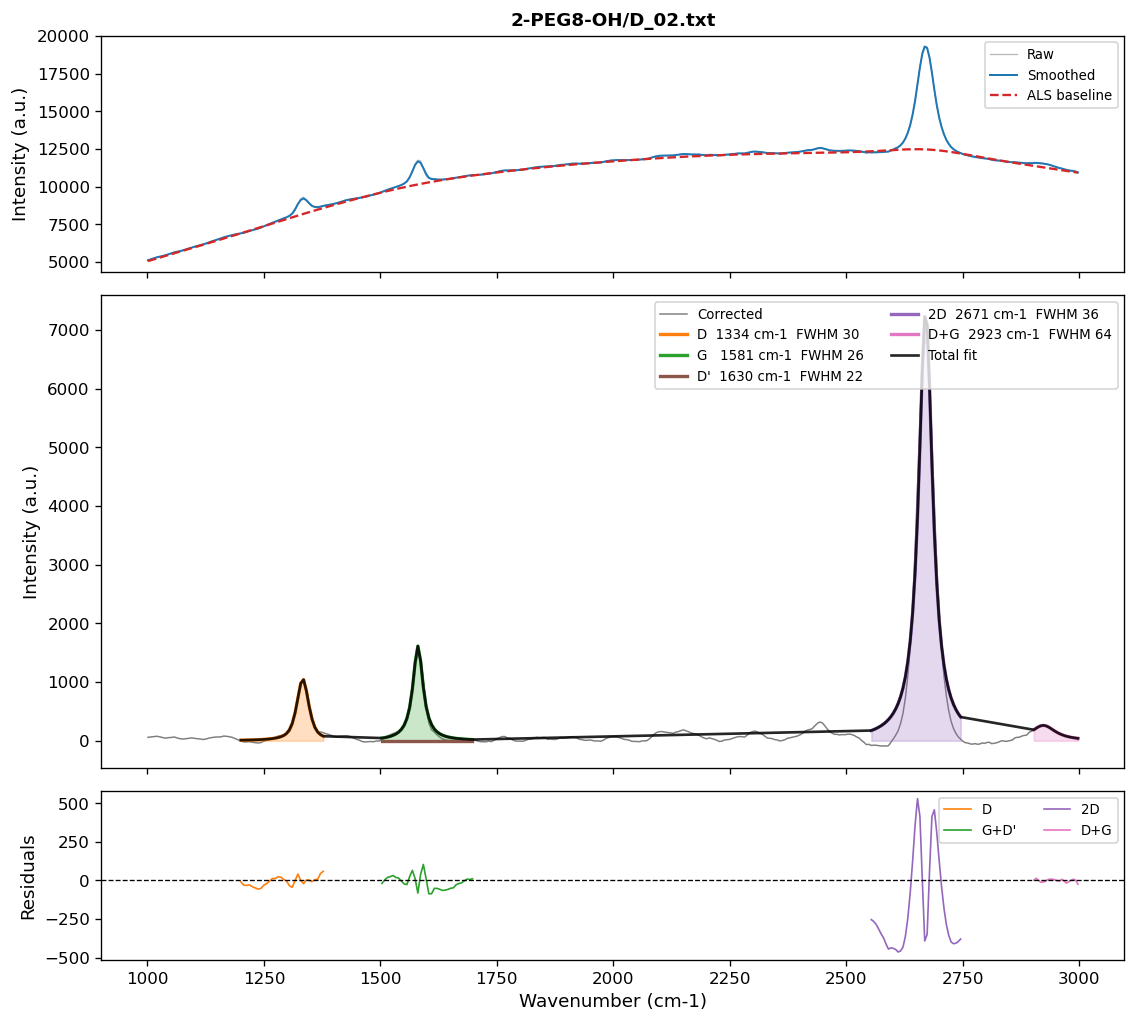


Peak           Centre     FWHM    Amplitude         Area      R2   RedChi2
------------------------------------------------------------------------
D(pV)          1333.5     30.4       1053.0      45173.0  0.9908 1016.1615
G              1580.8     26.3       1613.7      66773.1  0.9889 2488.1012
D'             1630.0     21.9          0.0          0.0  0.9889 2488.1012
2D             2670.6     36.4       7311.9     417984.4  0.9752 135514.7687
D+G            2923.2     64.1        262.2      26412.8  0.9860  106.8780

  ID/IG   (amplitude) = 0.6525
  I2D/IG  (amplitude) = 4.5311


In [18]:
TEST_FILE = list(ROOT.rglob('*.txt'))[0]   # change index to pick a different file
print('Testing:', TEST_FILE.relative_to(ROOT))

r = process_spectrum(TEST_FILE)
fig = plot_spectrum(r, title=str(TEST_FILE.relative_to(ROOT)))
plt.show()

print('\n{:8s} {:>12s} {:>8s} {:>12s} {:>12s} {:>7s} {:>9s}'.format(
    'Peak', 'Centre', 'FWHM', 'Amplitude', 'Area', 'R2', 'RedChi2'))
print('-' * 72)
for name, info in [('D(pV)', r['D']), ('G', r['G']), ("D'", r['Dp']),
                   ('2D', r['TwoD']), ('D+G', r['DG'])]:
    if info.get('success'):
        print('{:8s} {:>12.1f} {:>8.1f} {:>12.1f} {:>12.1f} {:>7.4f} {:>9.4f}'.format(
            name, info['position'], info['fwhm'],
            info['amplitude'], info['area'], info['rsq'], info['redchi']))
    else:
        print('{:8s}  not fitted'.format(name))
print()
print('  ID/IG   (amplitude) =', round(r['ID_IG'],  4))
print('  I2D/IG  (amplitude) =', round(r['I2D_IG'], 4))

---
## Cell 3 — Full analysis

TREATMENT: default

  -- Sample: 1-No_modification (3 replicate(s))


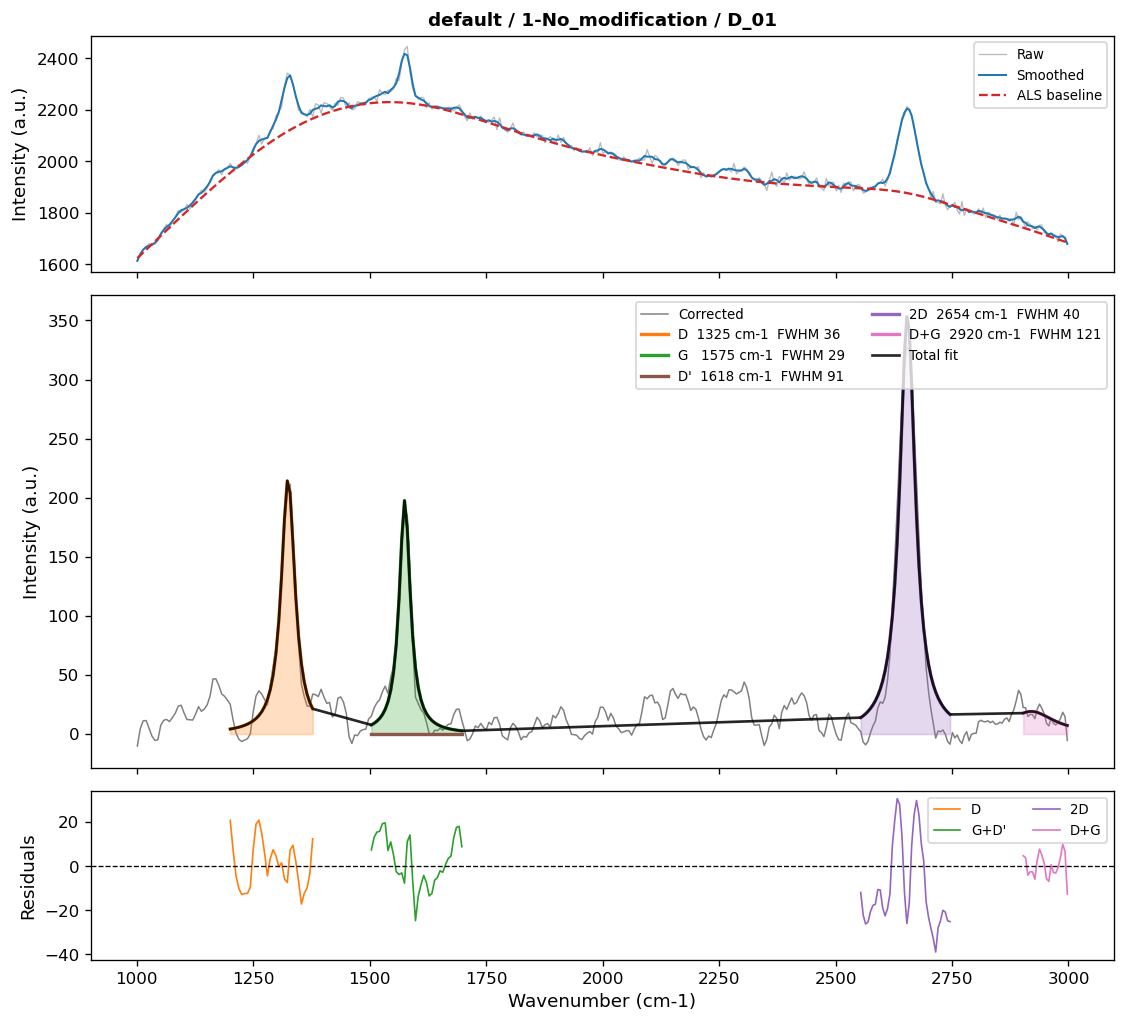

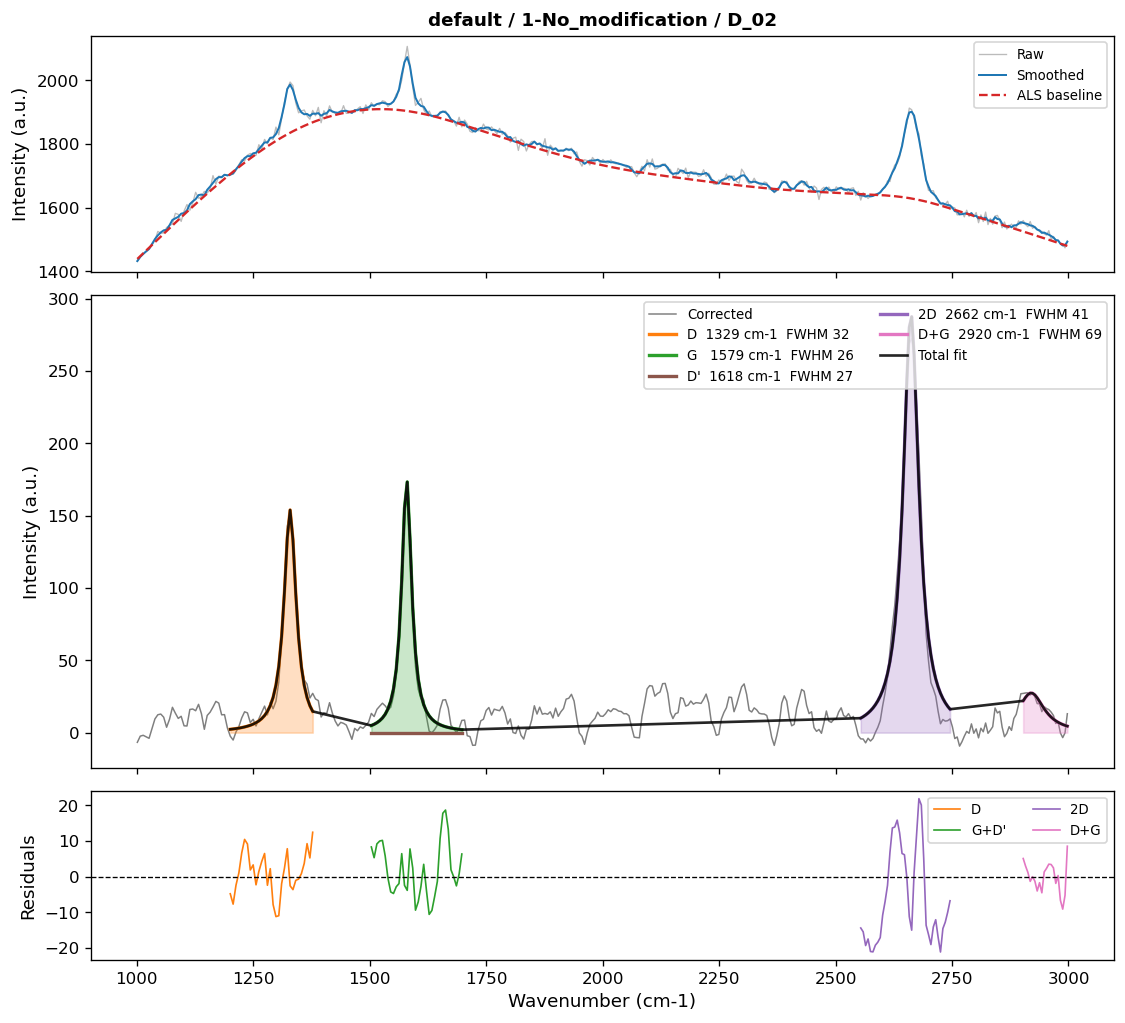

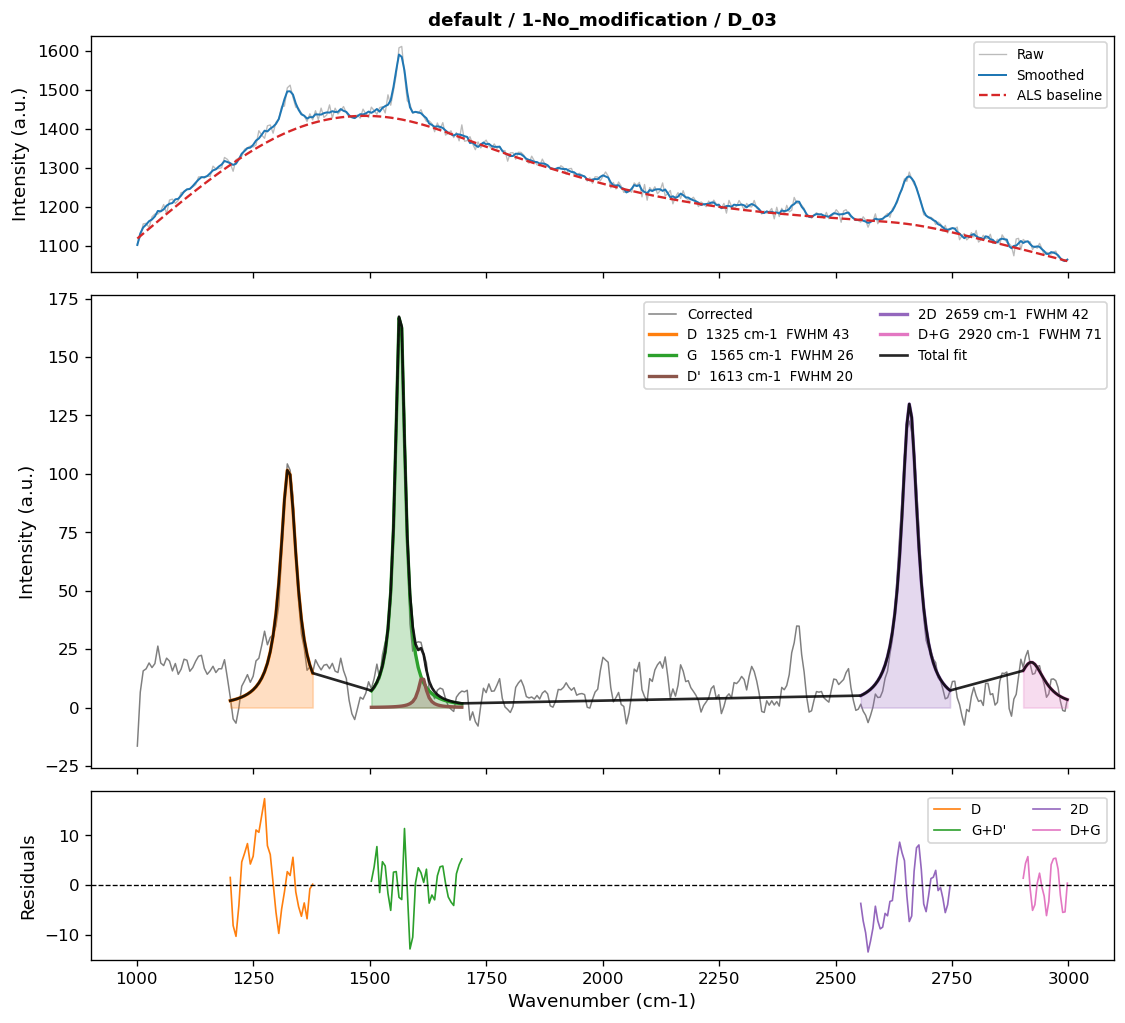

    ID/IG:  0.855 +/- 0.205
    I2D/IG:  1.398 +/- 0.462

  -- Sample: 2-PEG8-OH (3 replicate(s))


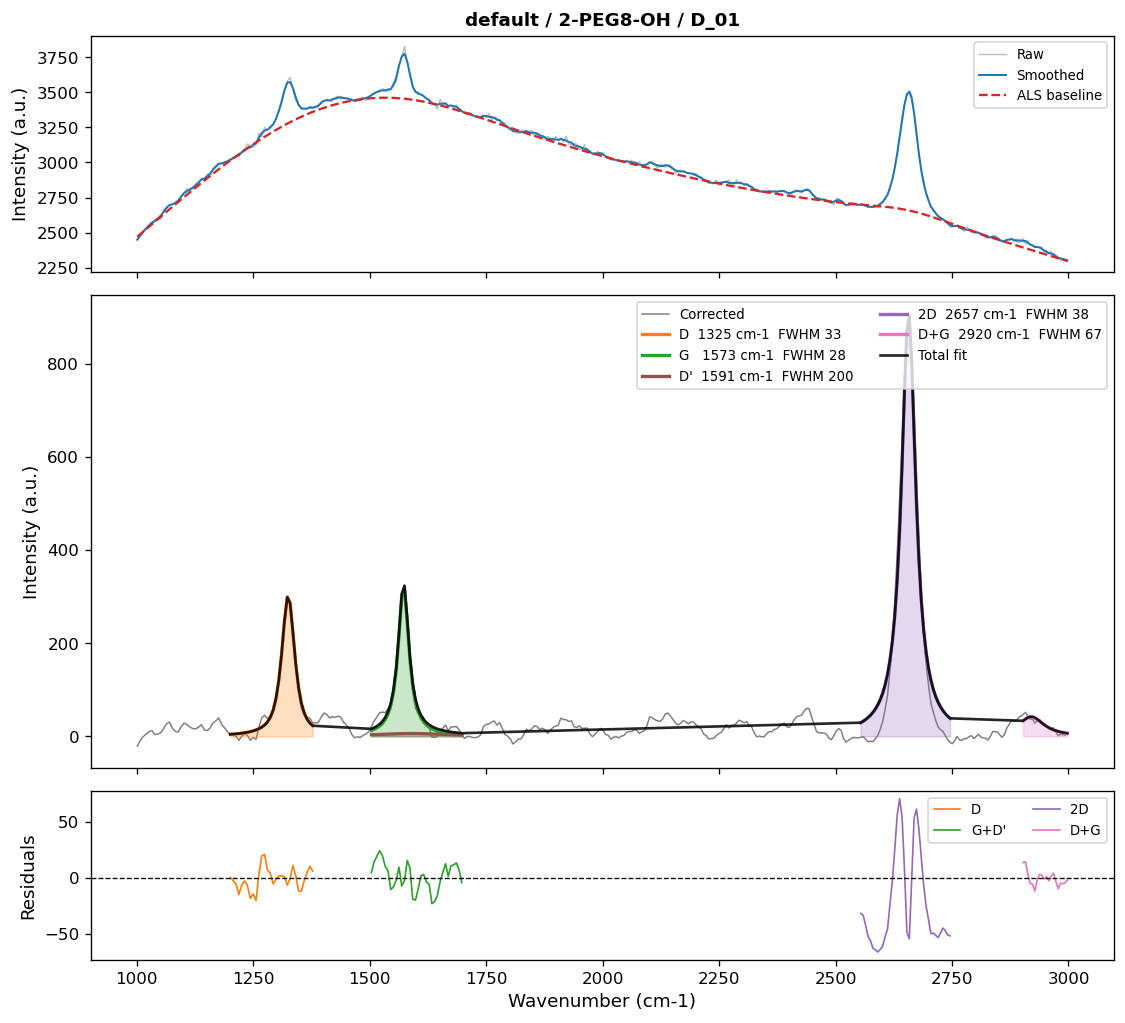

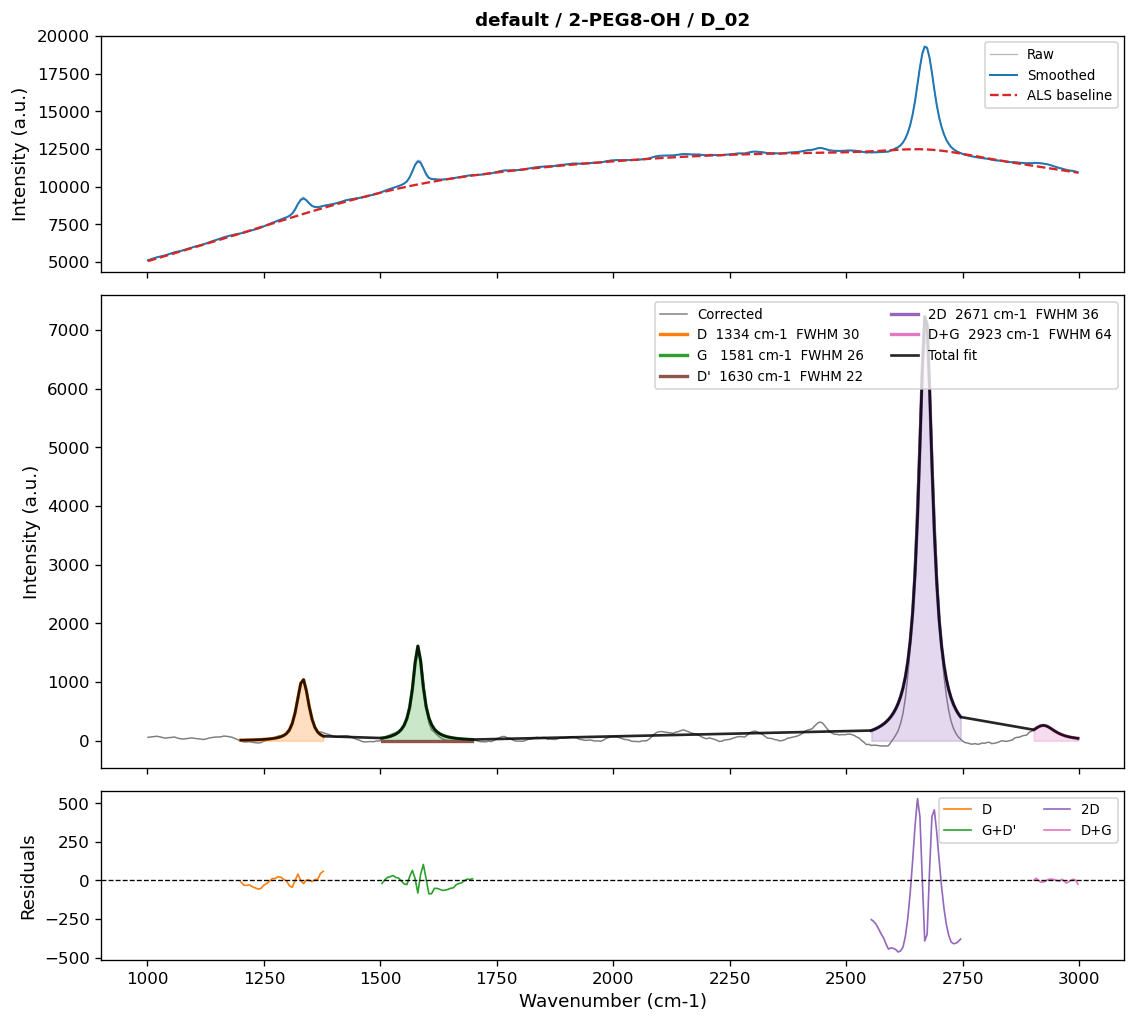

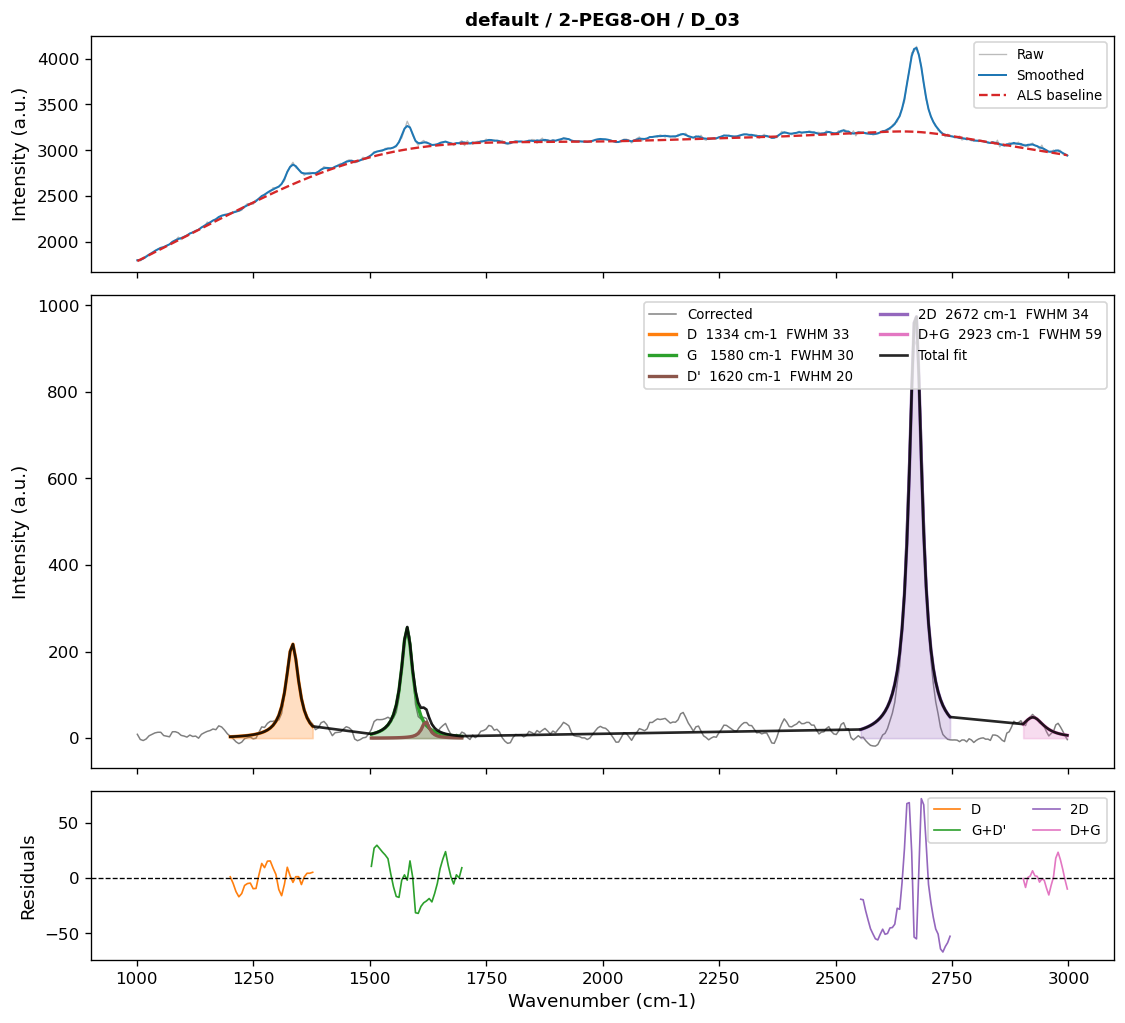

    ID/IG:  0.814 +/- 0.119
    I2D/IG:  3.737 +/- 0.715

  -- Sample: 3-PEG2K-NH2 (4 replicate(s))


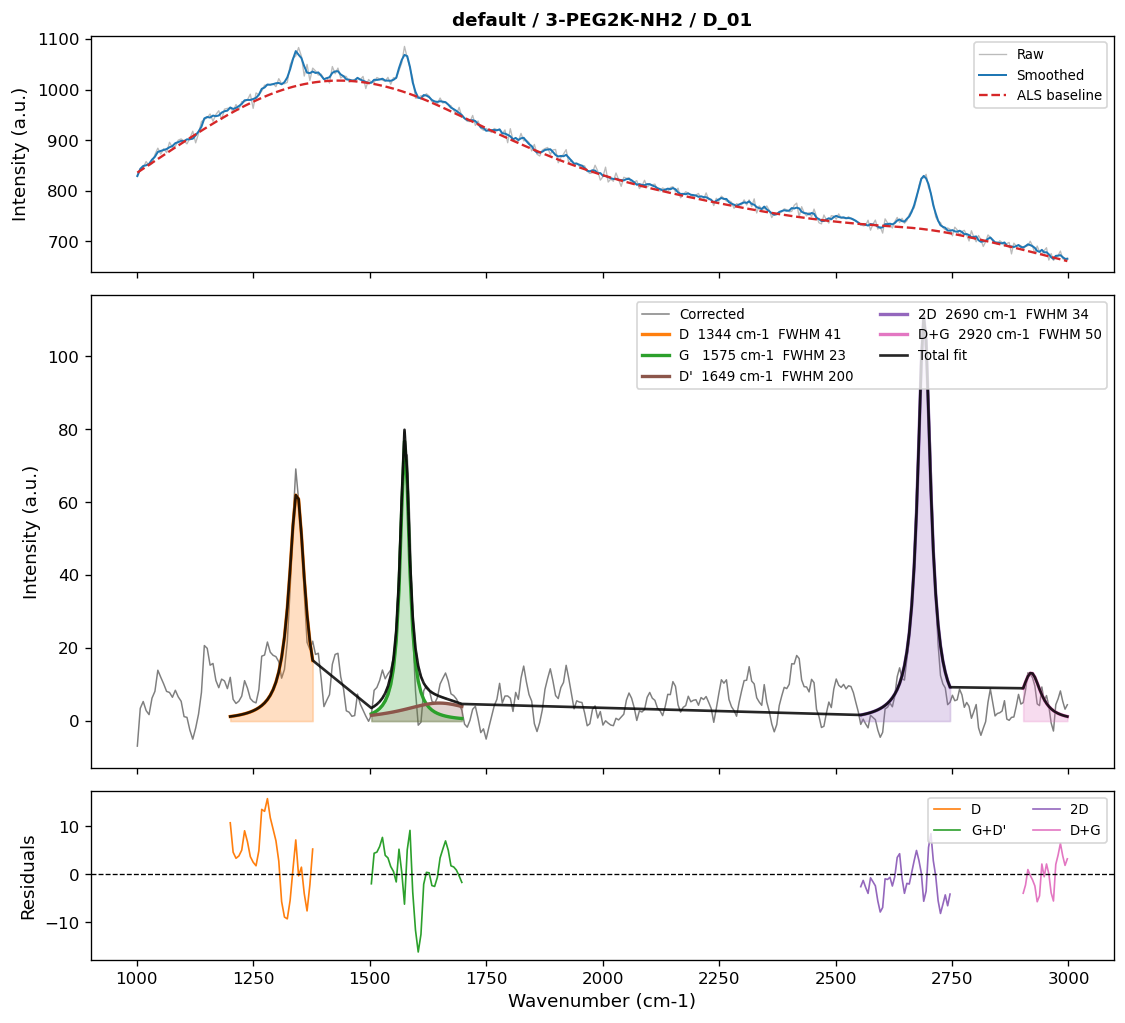

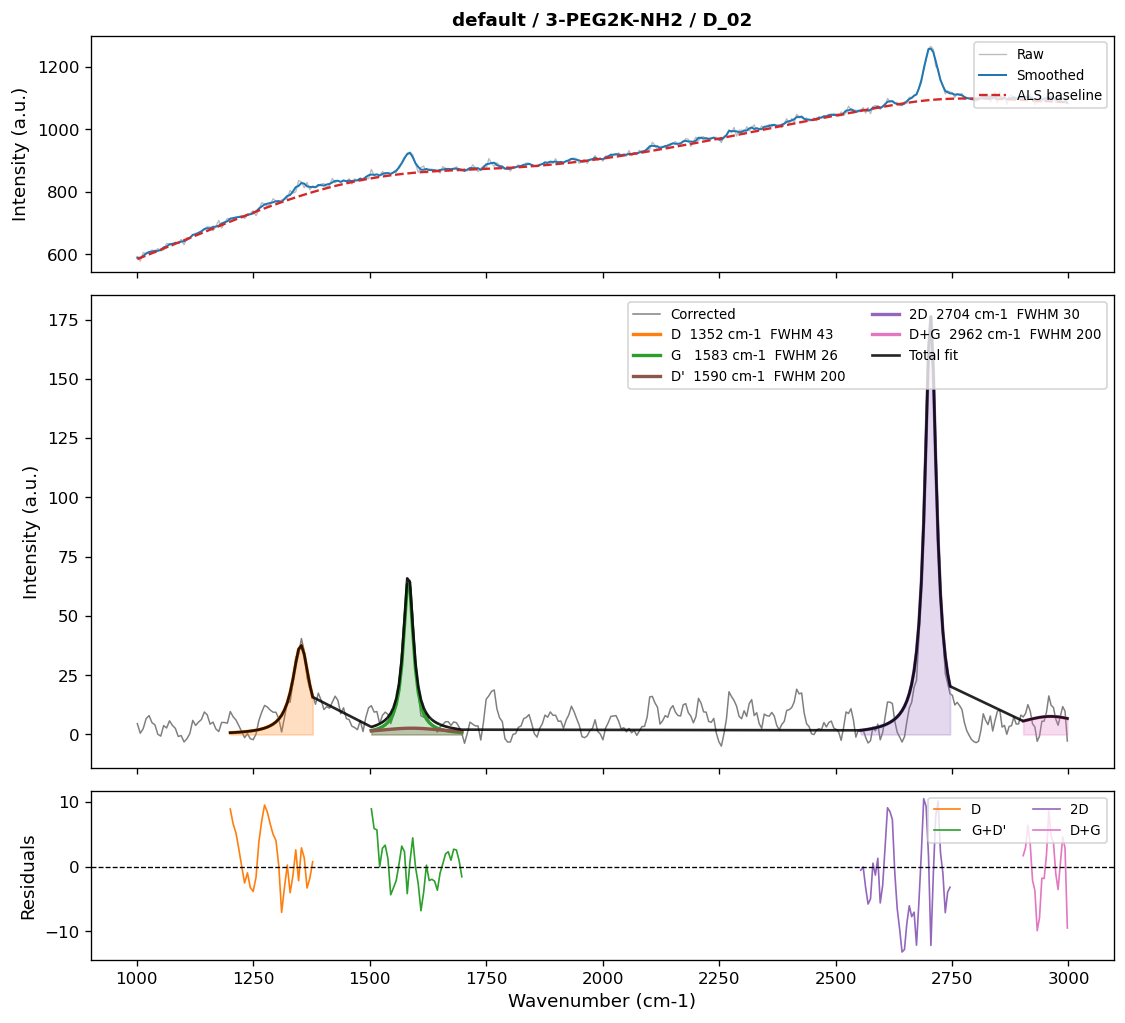

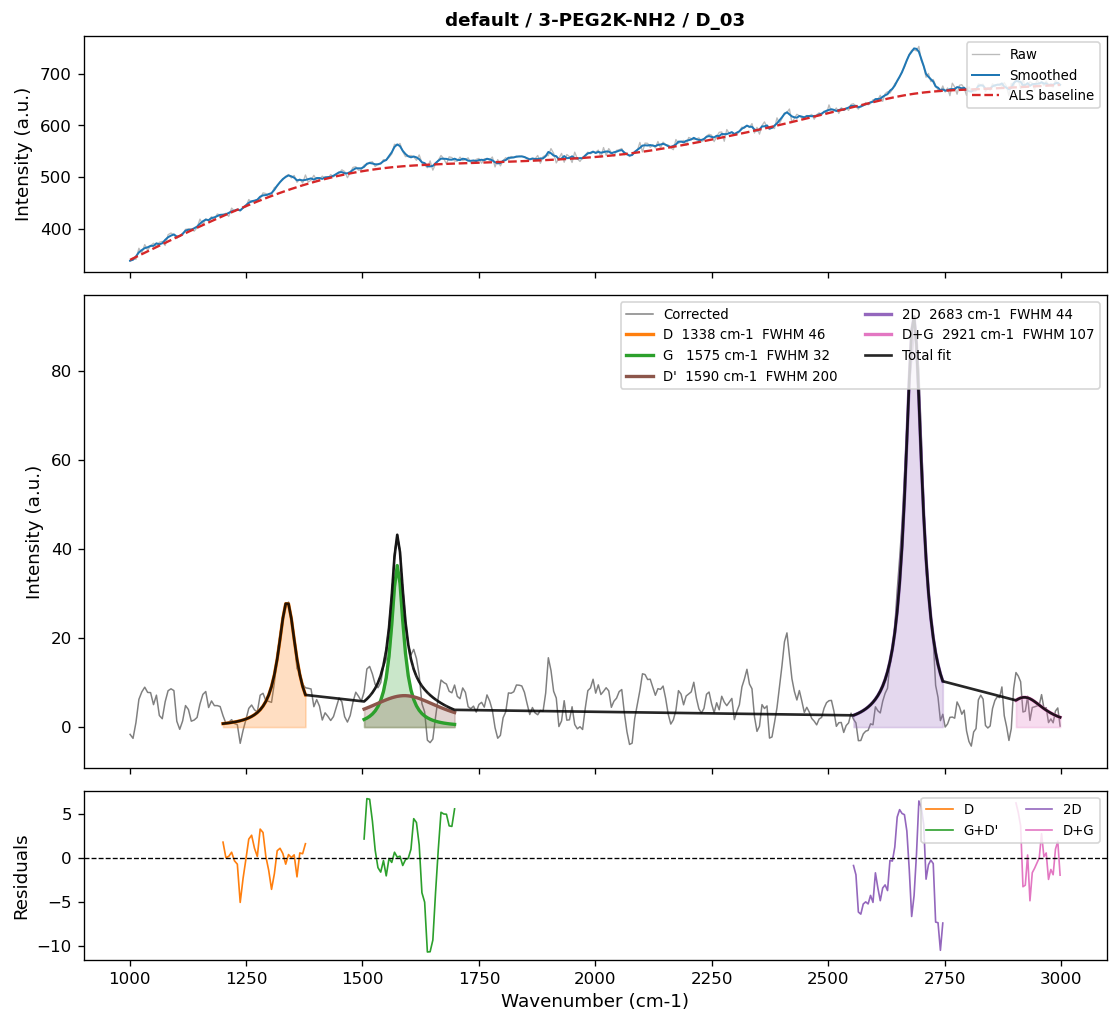

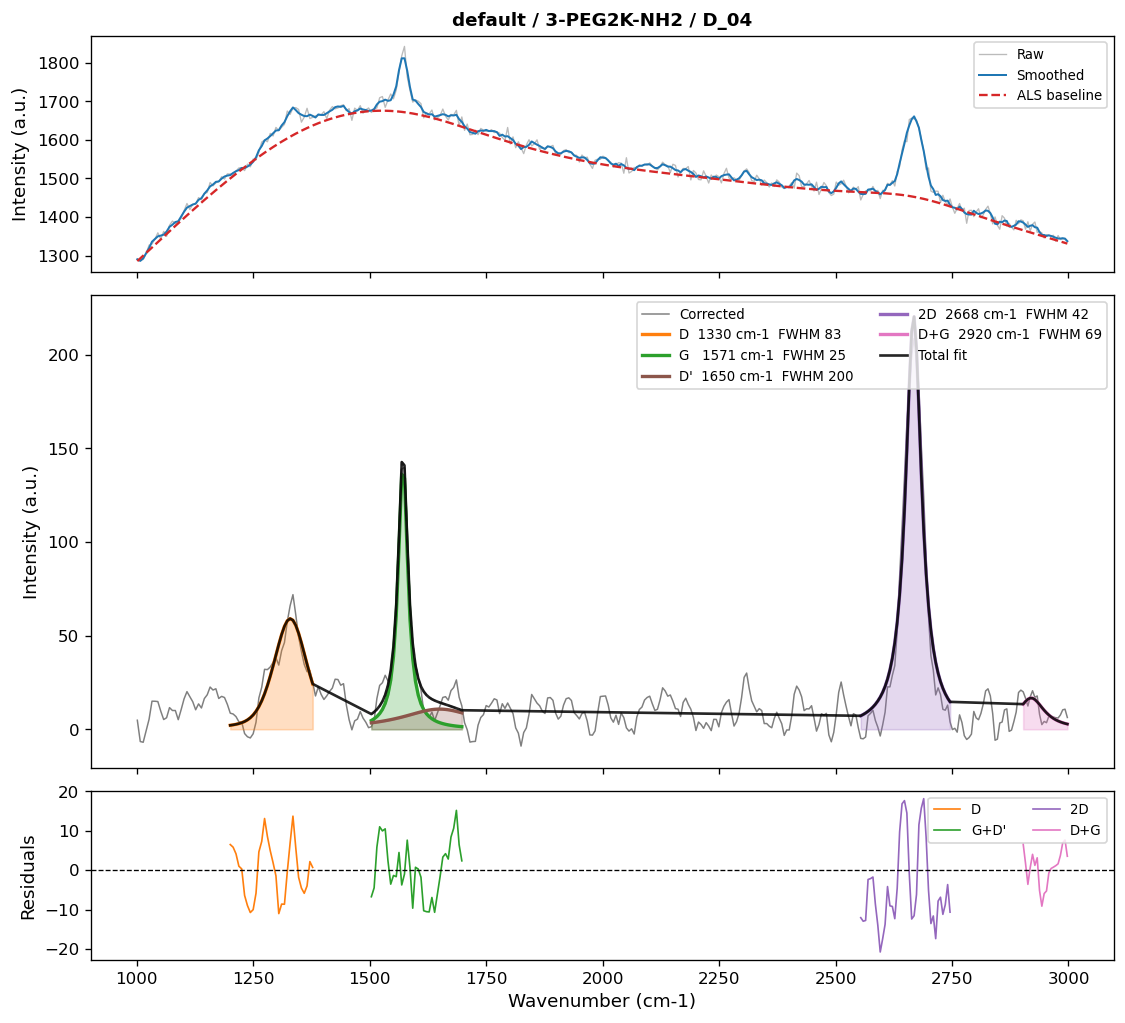

    ID/IG:  0.645 +/- 0.162
    I2D/IG:  2.055 +/- 0.563

  -- Sample: 4-PEG2K-COOH (3 replicate(s))


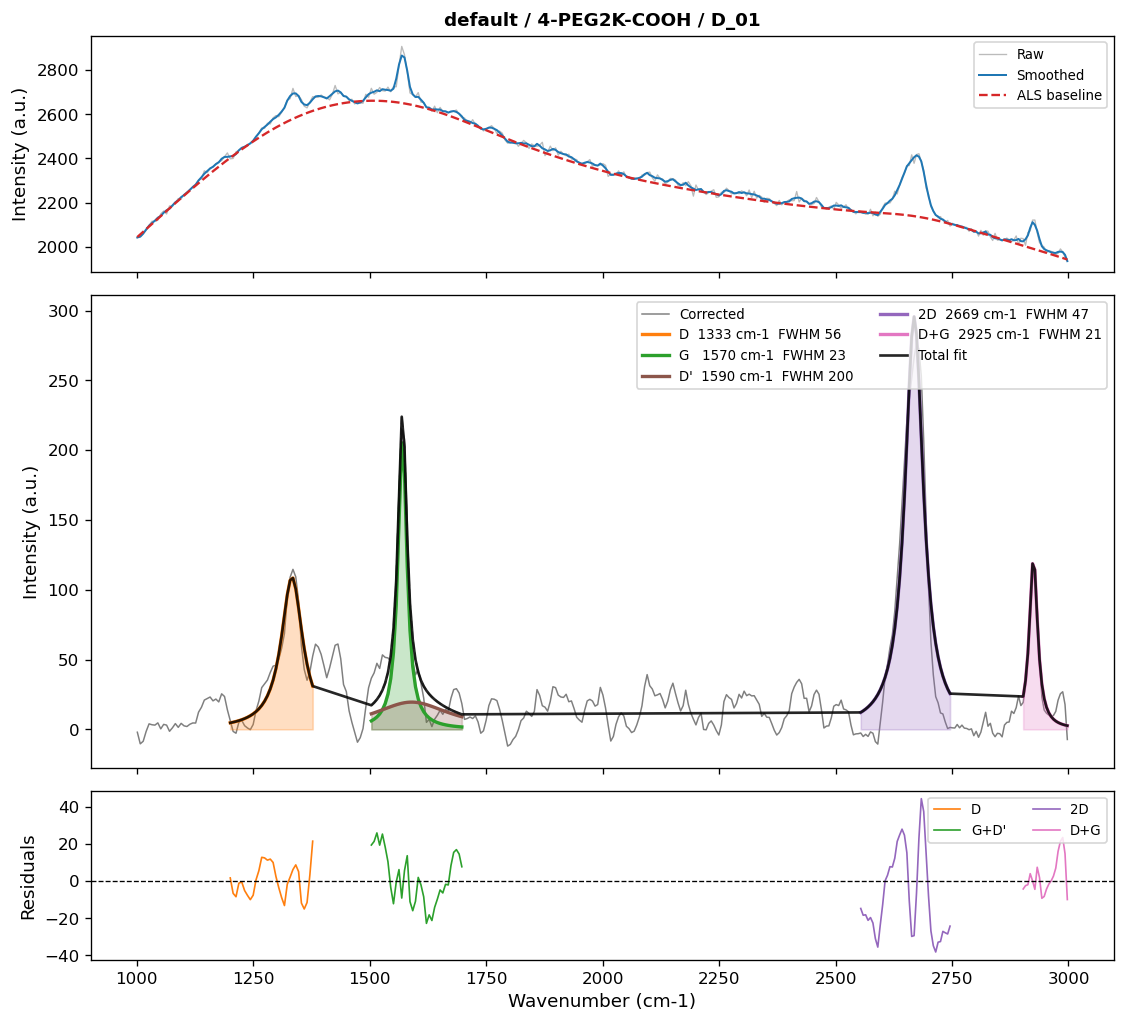

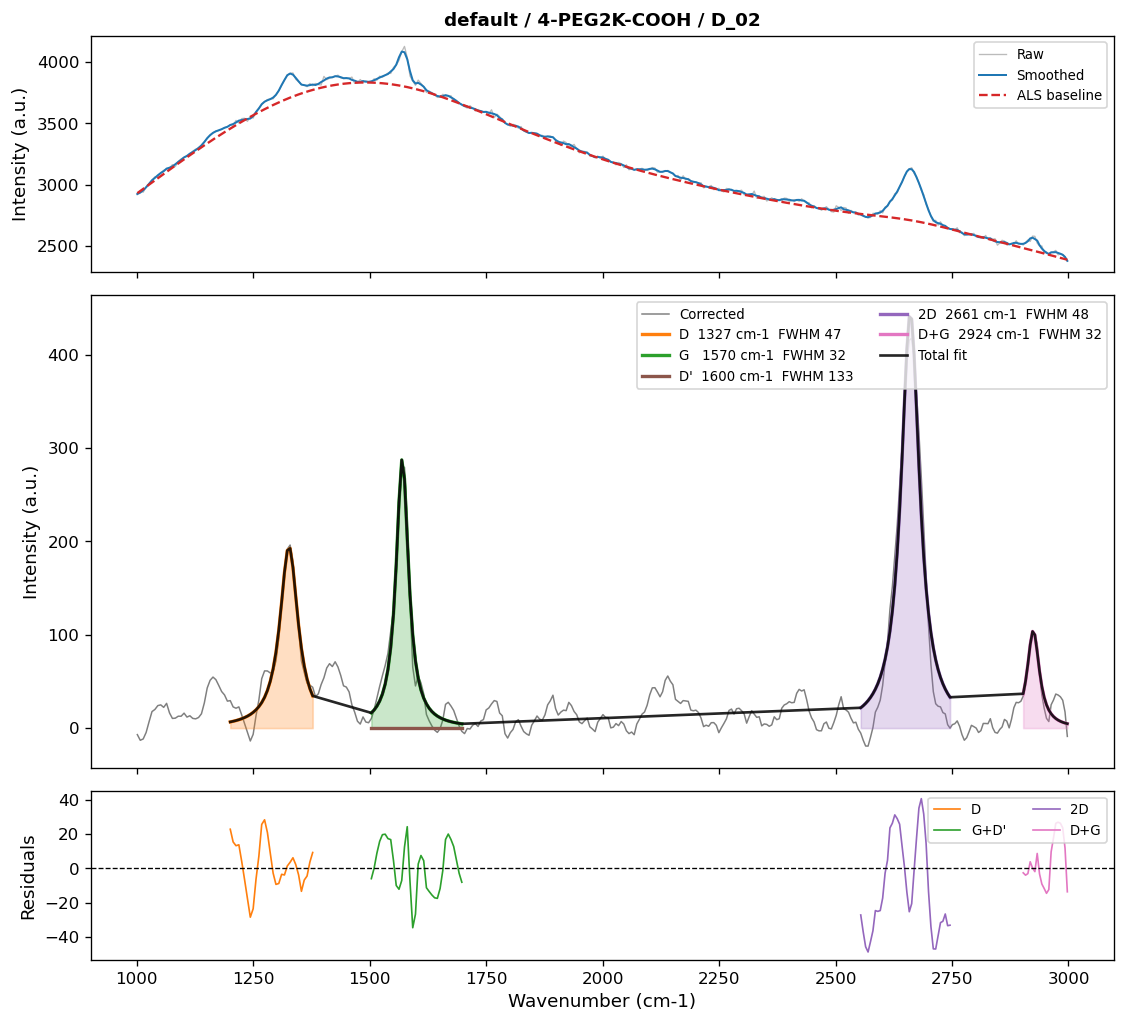

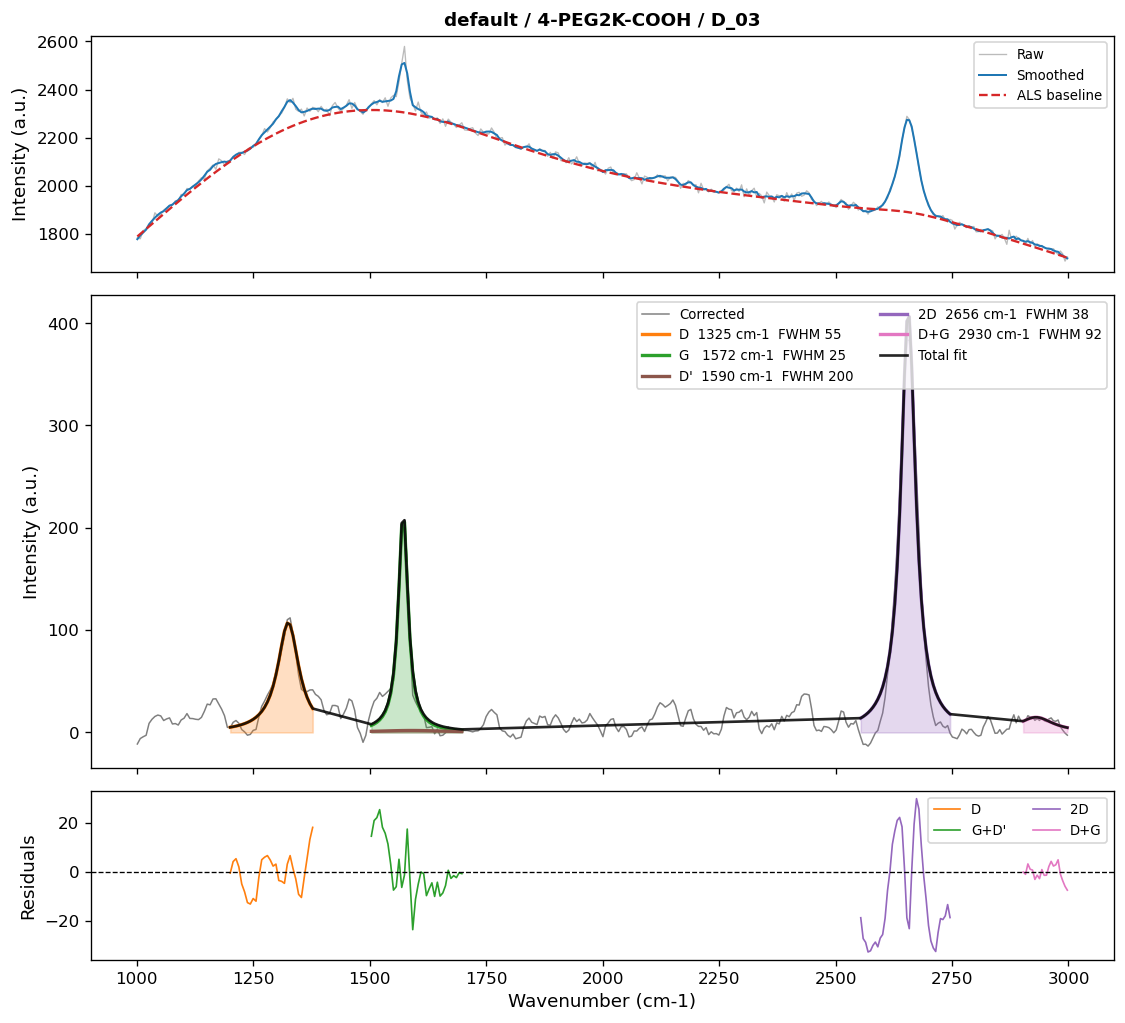

    ID/IG:  0.564 +/- 0.078
    I2D/IG:  1.620 +/- 0.210

  -- Sample: 5-PEG8-OH&PEG2K-NH2 (2 replicate(s))


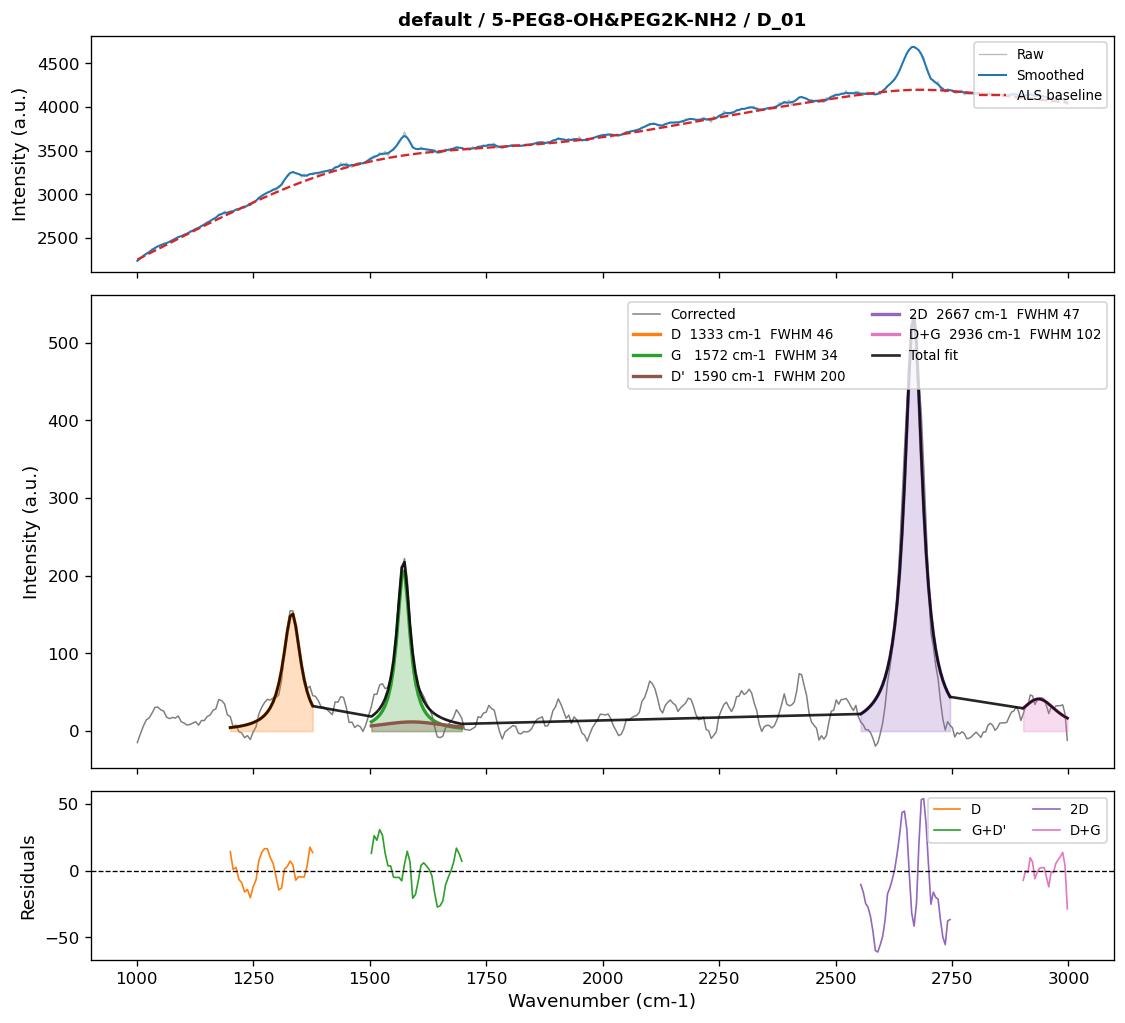

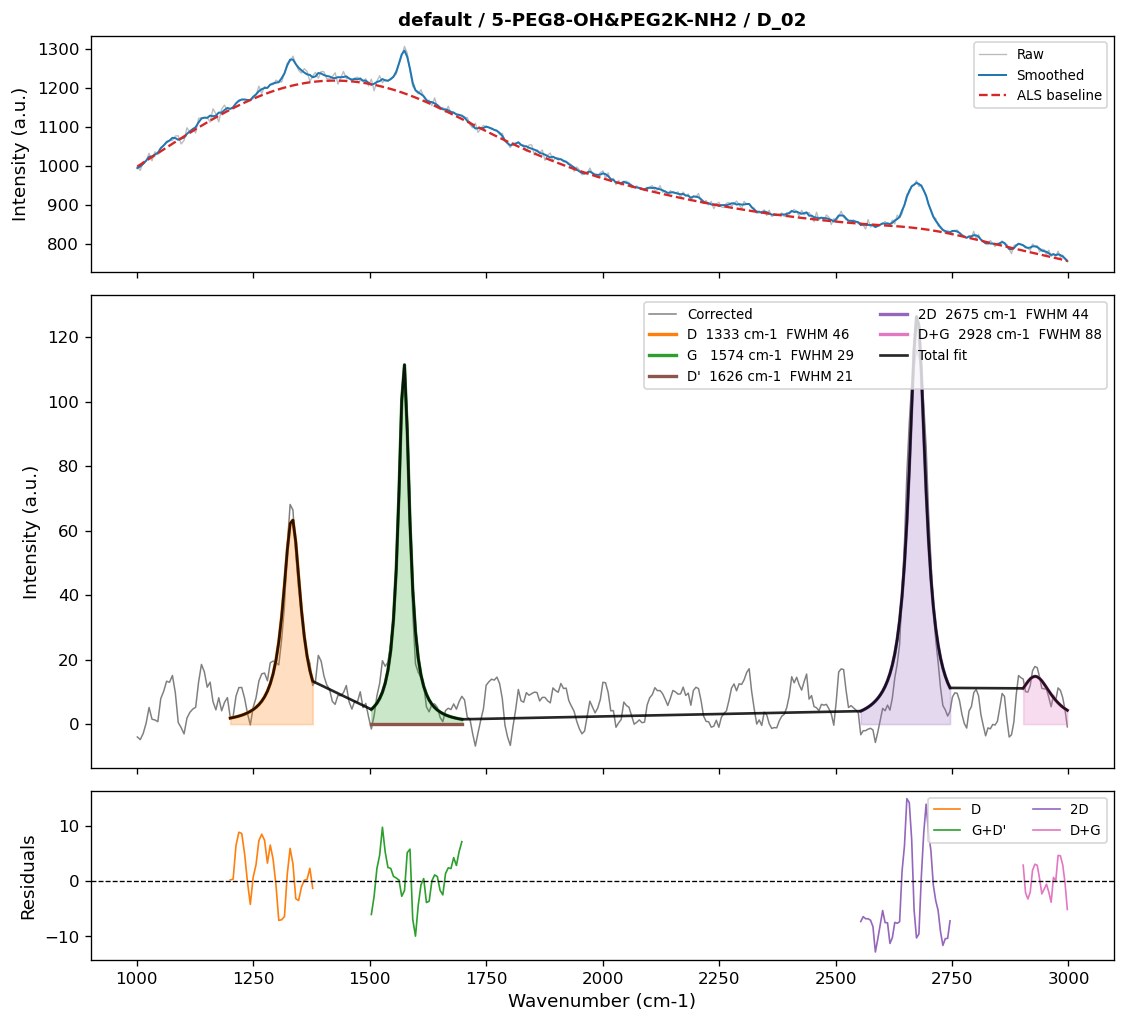

    ID/IG:  0.649 +/- 0.078
    I2D/IG:  1.845 +/- 0.711

  -- Sample: 6-PEG8-OH&PEG2K-COOH (3 replicate(s))


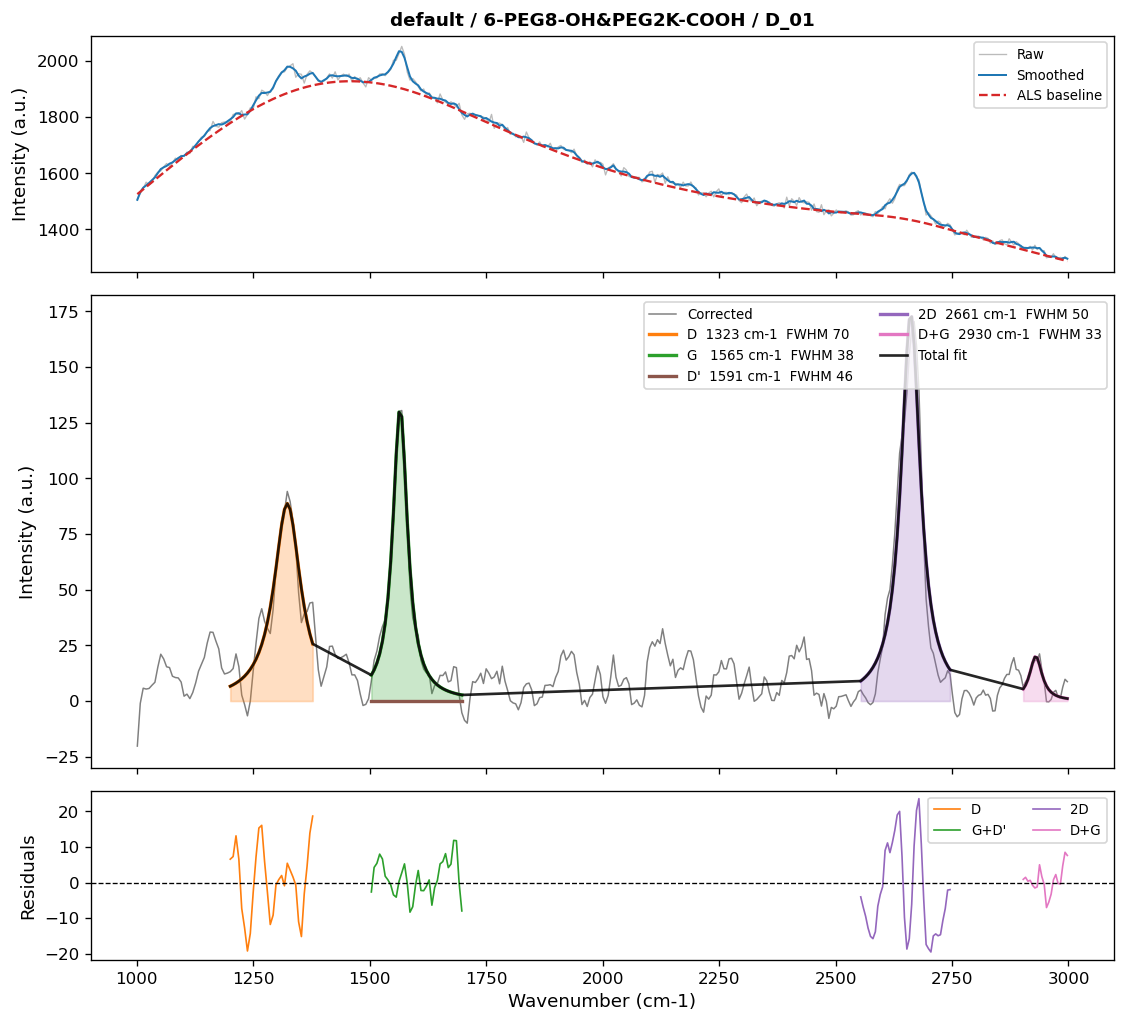

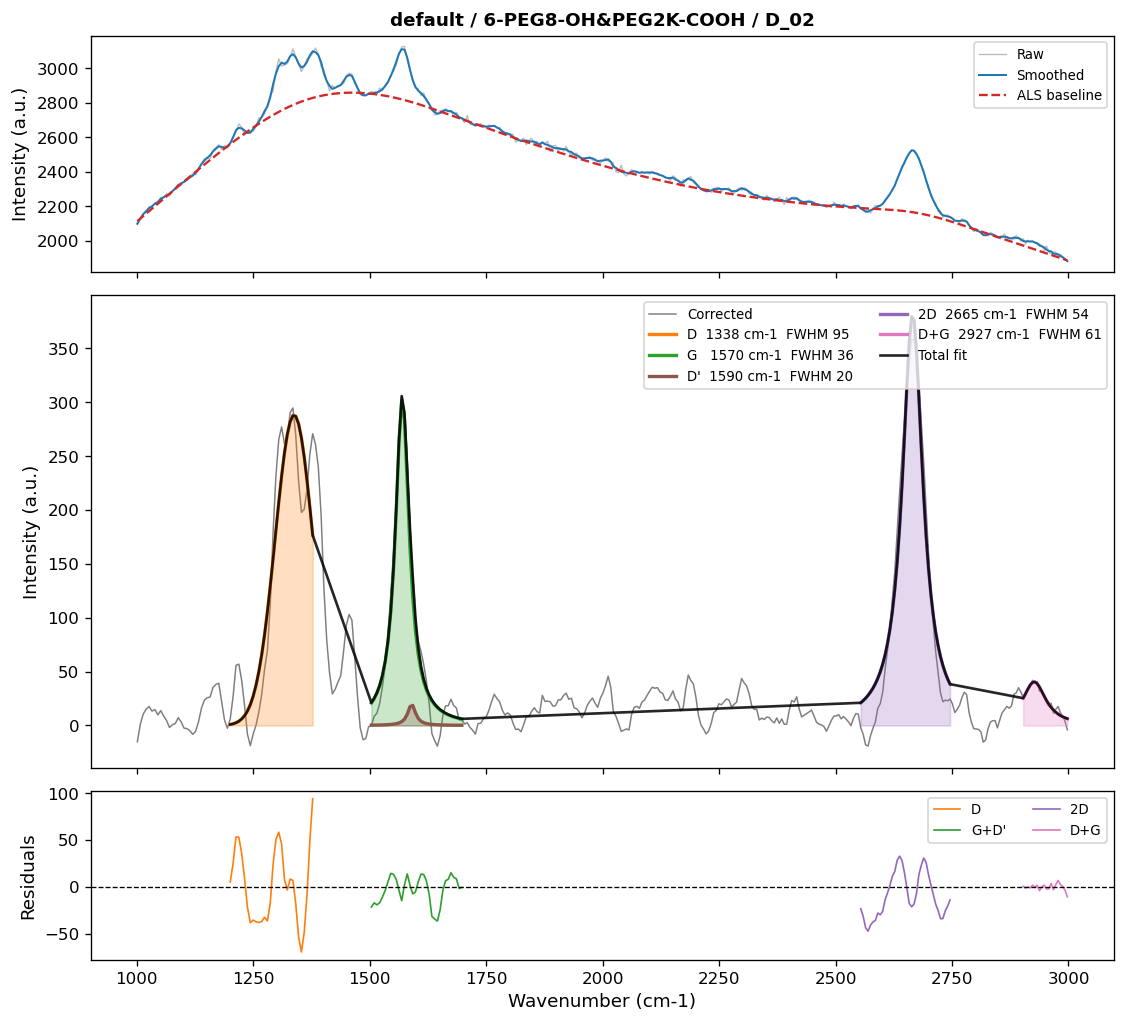

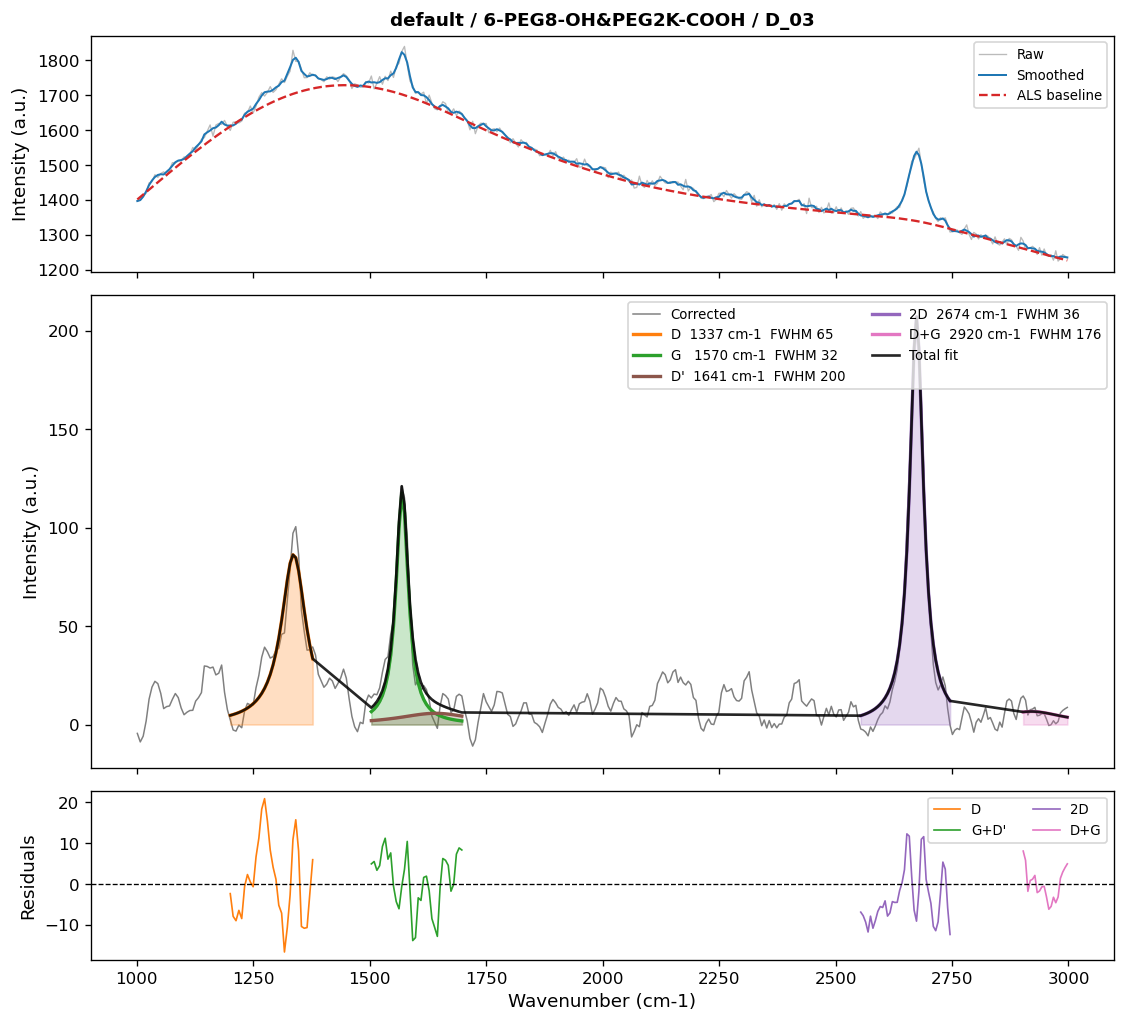

    ID/IG:  0.786 +/- 0.119
    I2D/IG:  1.445 +/- 0.224

  -- Sample: 7-PEG1K-NH2 (3 replicate(s))


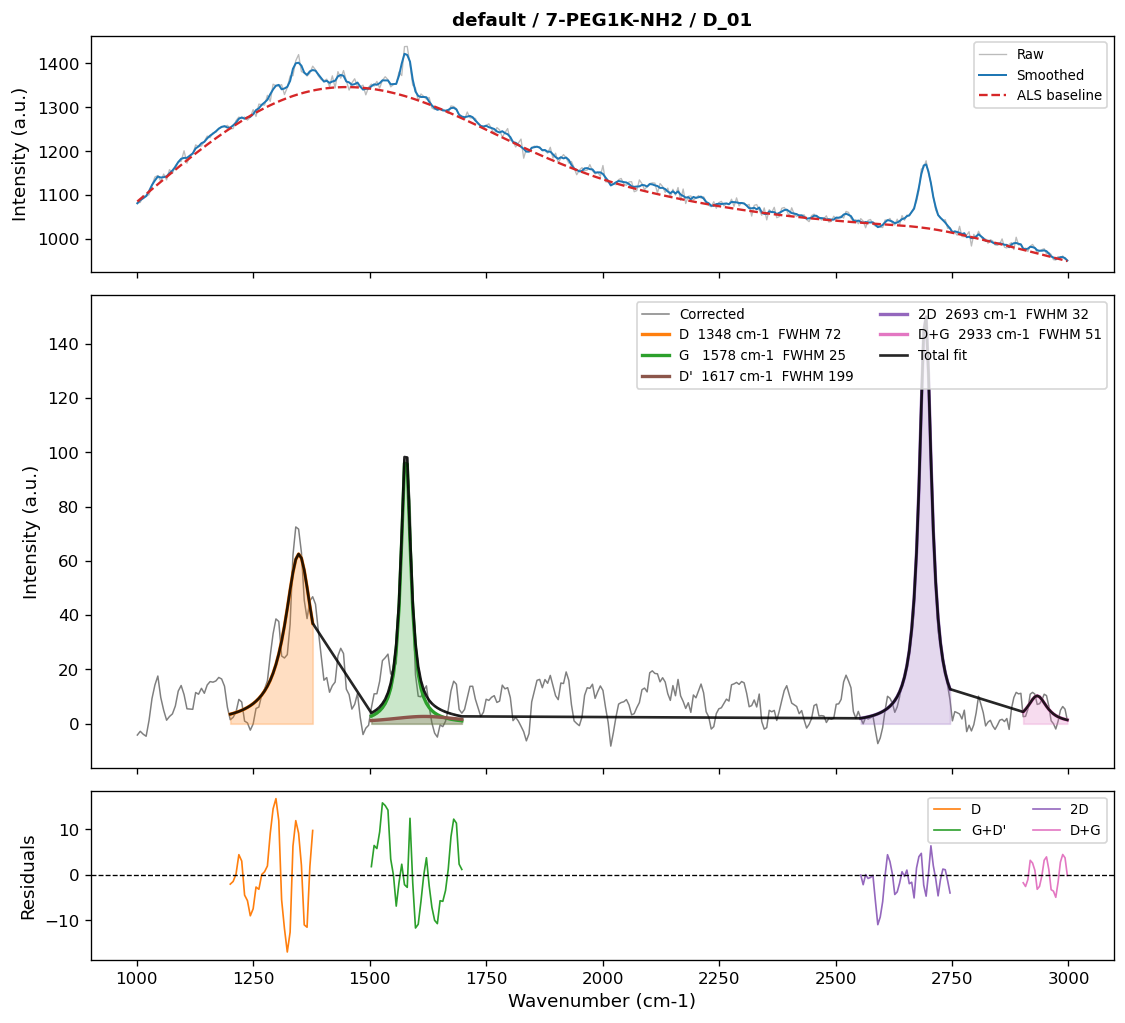

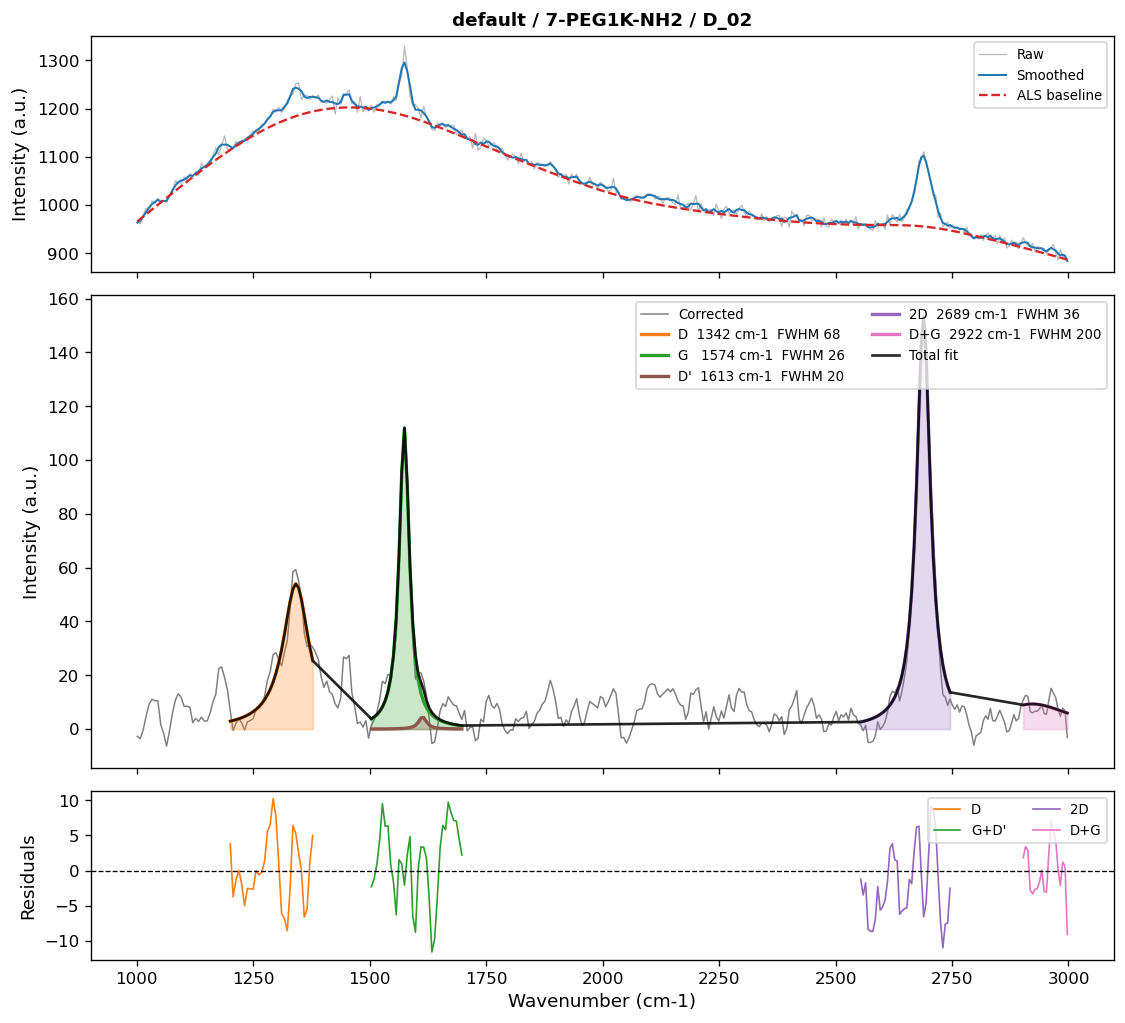

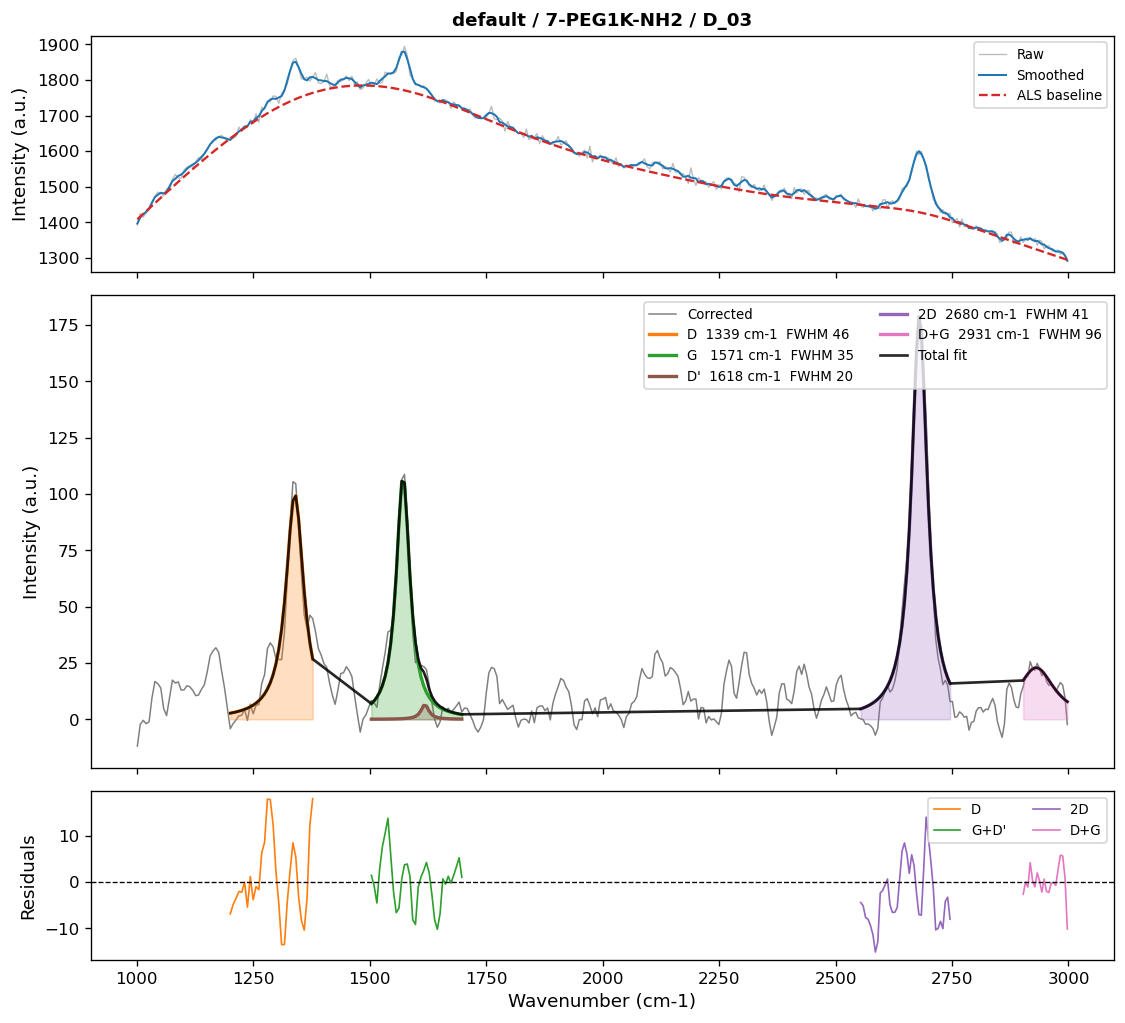

    ID/IG:  0.675 +/- 0.185
    I2D/IG:  1.509 +/- 0.118

  -- Sample: 8-PEG8-OH&PEG1K-NH2 (3 replicate(s))


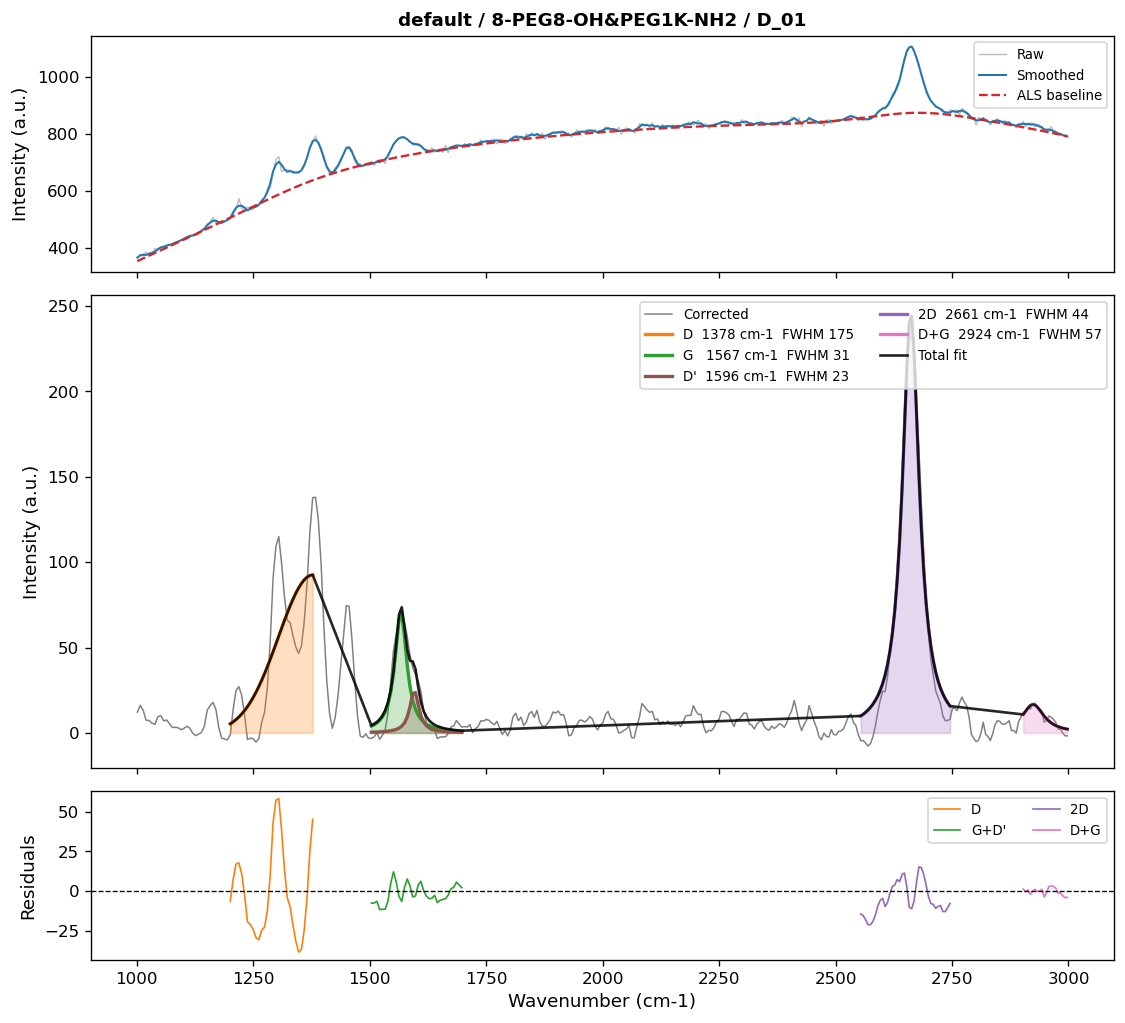

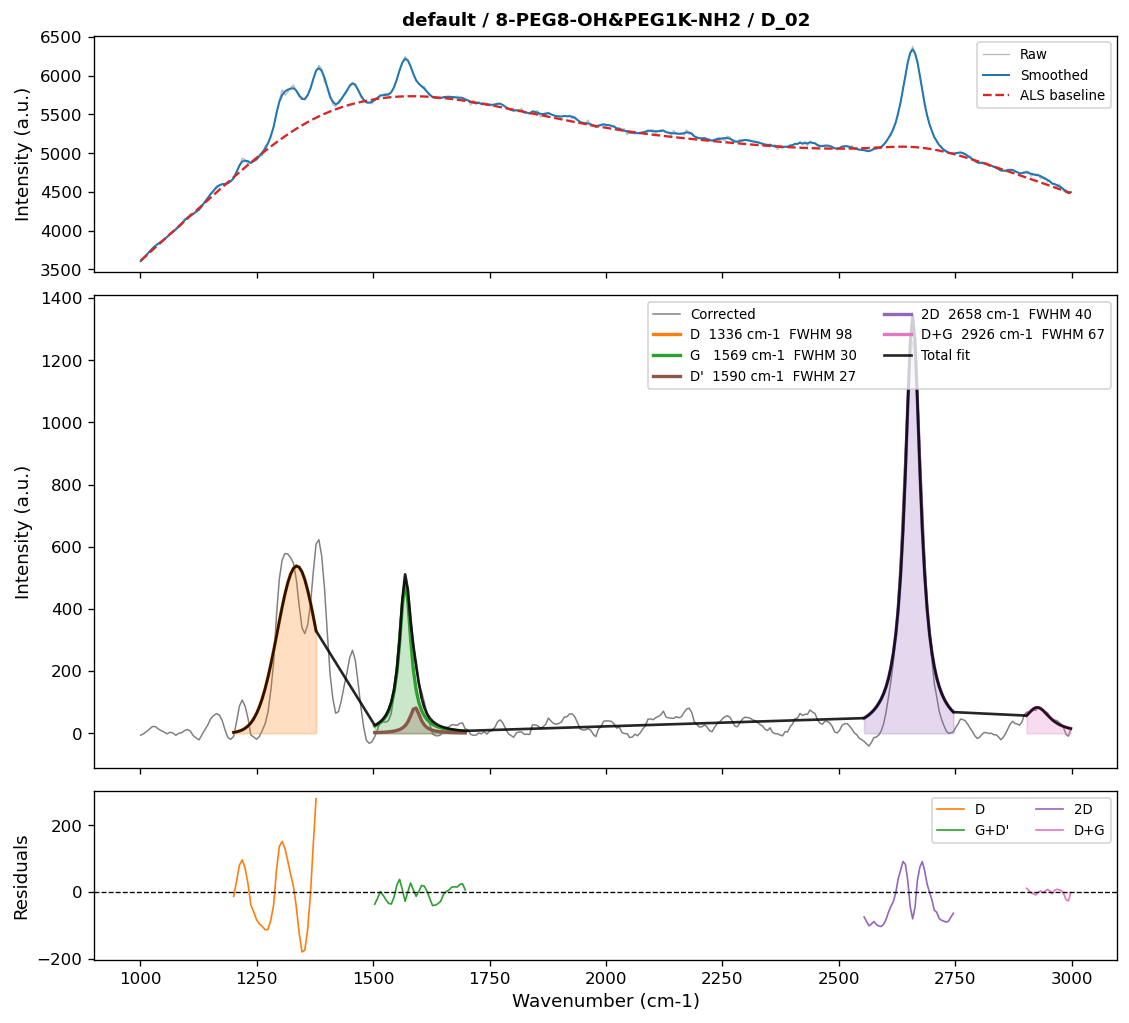

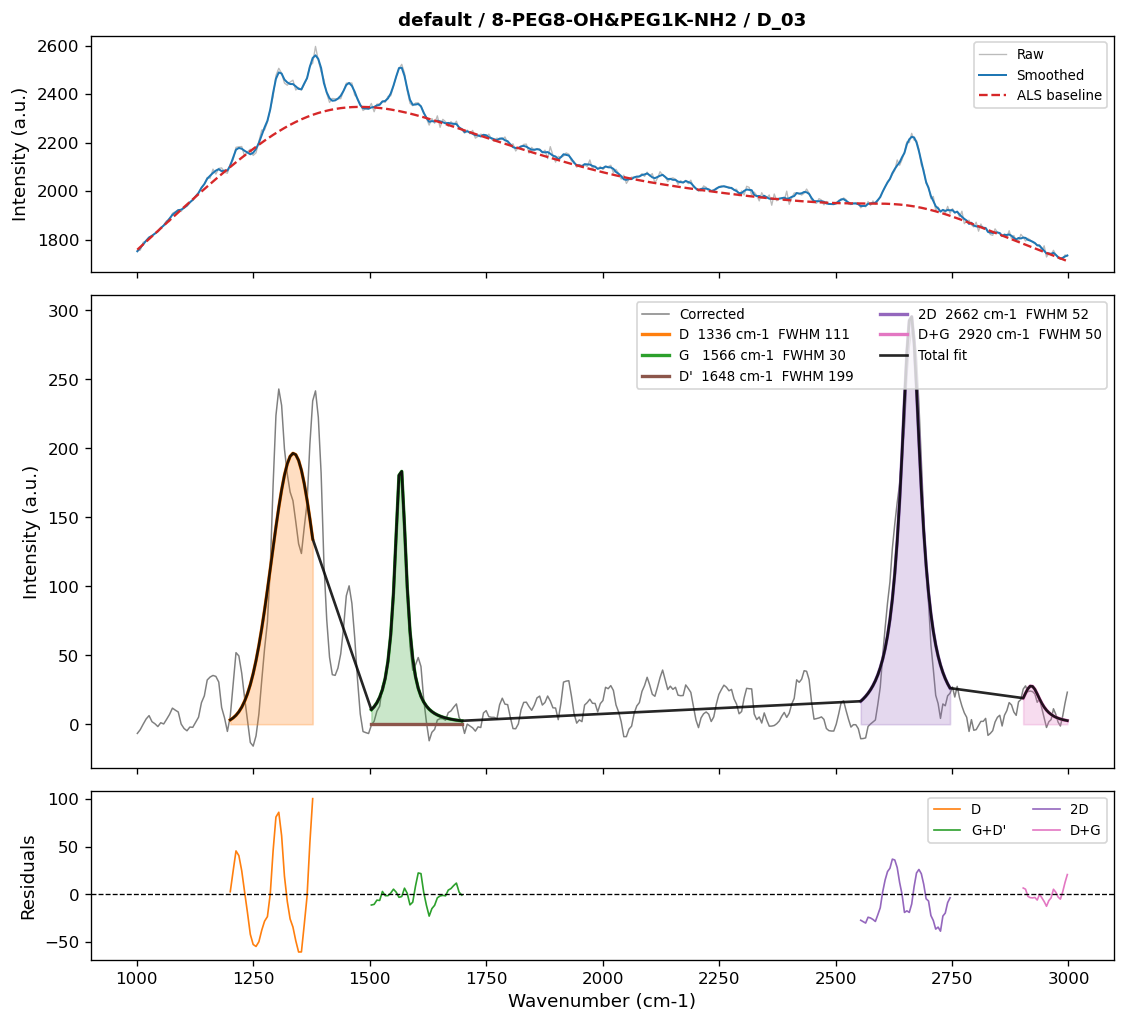

    ID/IG:  1.151 +/- 0.114
    I2D/IG:  2.599 +/- 0.783


In [37]:
all_rows = []
t_list   = list(TREE.keys())
# change plot color in cell 4 here by t_color
# t_color = {t: 'black' for t in t_list}
t_color = {
    t: plt.colormaps['Greys'](0.4 + 0.6 * i / max(len(t_list)-1, 1))
    for i, t in enumerate(t_list)
}
#t_color  = {t: plt.colormaps['Set1'](i / max(len(t_list)-1, 1))
#            for i, t in enumerate(t_list)}

for treatment, samples in TREE.items():
    print('=' * 60)
    print('TREATMENT:', treatment)
    print('=' * 60)

    for sample, files in samples.items():
        print('\n  -- Sample:', sample, '(%d replicate(s))' % len(files))
        results = []

        for f in files:
            try:
                r = process_spectrum(f)
                r['label'] = f.stem
                results.append(r)
                all_rows.append(dict(
                    treatment=treatment, sample=sample, file=f.name,
                    D_pos=r['D']['position'],    D_fwhm=r['D']['fwhm'],
                    D_amp=r['D']['amplitude'],   D_area=r['D']['area'],
                    D_eta=r['D'].get('eta', np.nan), D_rsq=r['D']['rsq'],
                    G_pos=r['G']['position'],    G_fwhm=r['G']['fwhm'],
                    G_amp=r['G']['amplitude'],   G_area=r['G']['area'],
                    G_rsq=r['G']['rsq'],
                    Dp_pos=r['Dp']['position'],  Dp_fwhm=r['Dp']['fwhm'],
                    Dp_area=r['Dp']['area'],
                    TwoD_pos=r['TwoD']['position'],  TwoD_fwhm=r['TwoD']['fwhm'],
                    TwoD_area=r['TwoD']['area'],     TwoD_rsq=r['TwoD']['rsq'],
                    DG_pos=r['DG']['position'],  DG_area=r['DG']['area'],
                    ID_IG=r['ID_IG'], I2D_IG=r['I2D_IG'],
                ))
            except Exception as e:
                print('    SKIP', f.name + ':', e)

        if not results:
            continue

        # plot each replicate
        for r in results:
            fig = plot_spectrum(
                r, title=treatment + ' / ' + sample + ' / ' + r['label'])
            fig.savefig(
                OUTPUT_DIR / (treatment + '_' + sample + '_' + r['label'] + '.png'),
                bbox_inches='tight', dpi=150)
            plt.show()

        # per-sample summary
        for metric, lbl in [('ID_IG', 'ID/IG'), ('I2D_IG', 'I2D/IG')]:
            vals = [rv[metric] for rv in results if not np.isnan(rv[metric])]
            if vals:
                print('    %s:  %.3f +/- %.3f' % (lbl, np.mean(vals), np.std(vals)))

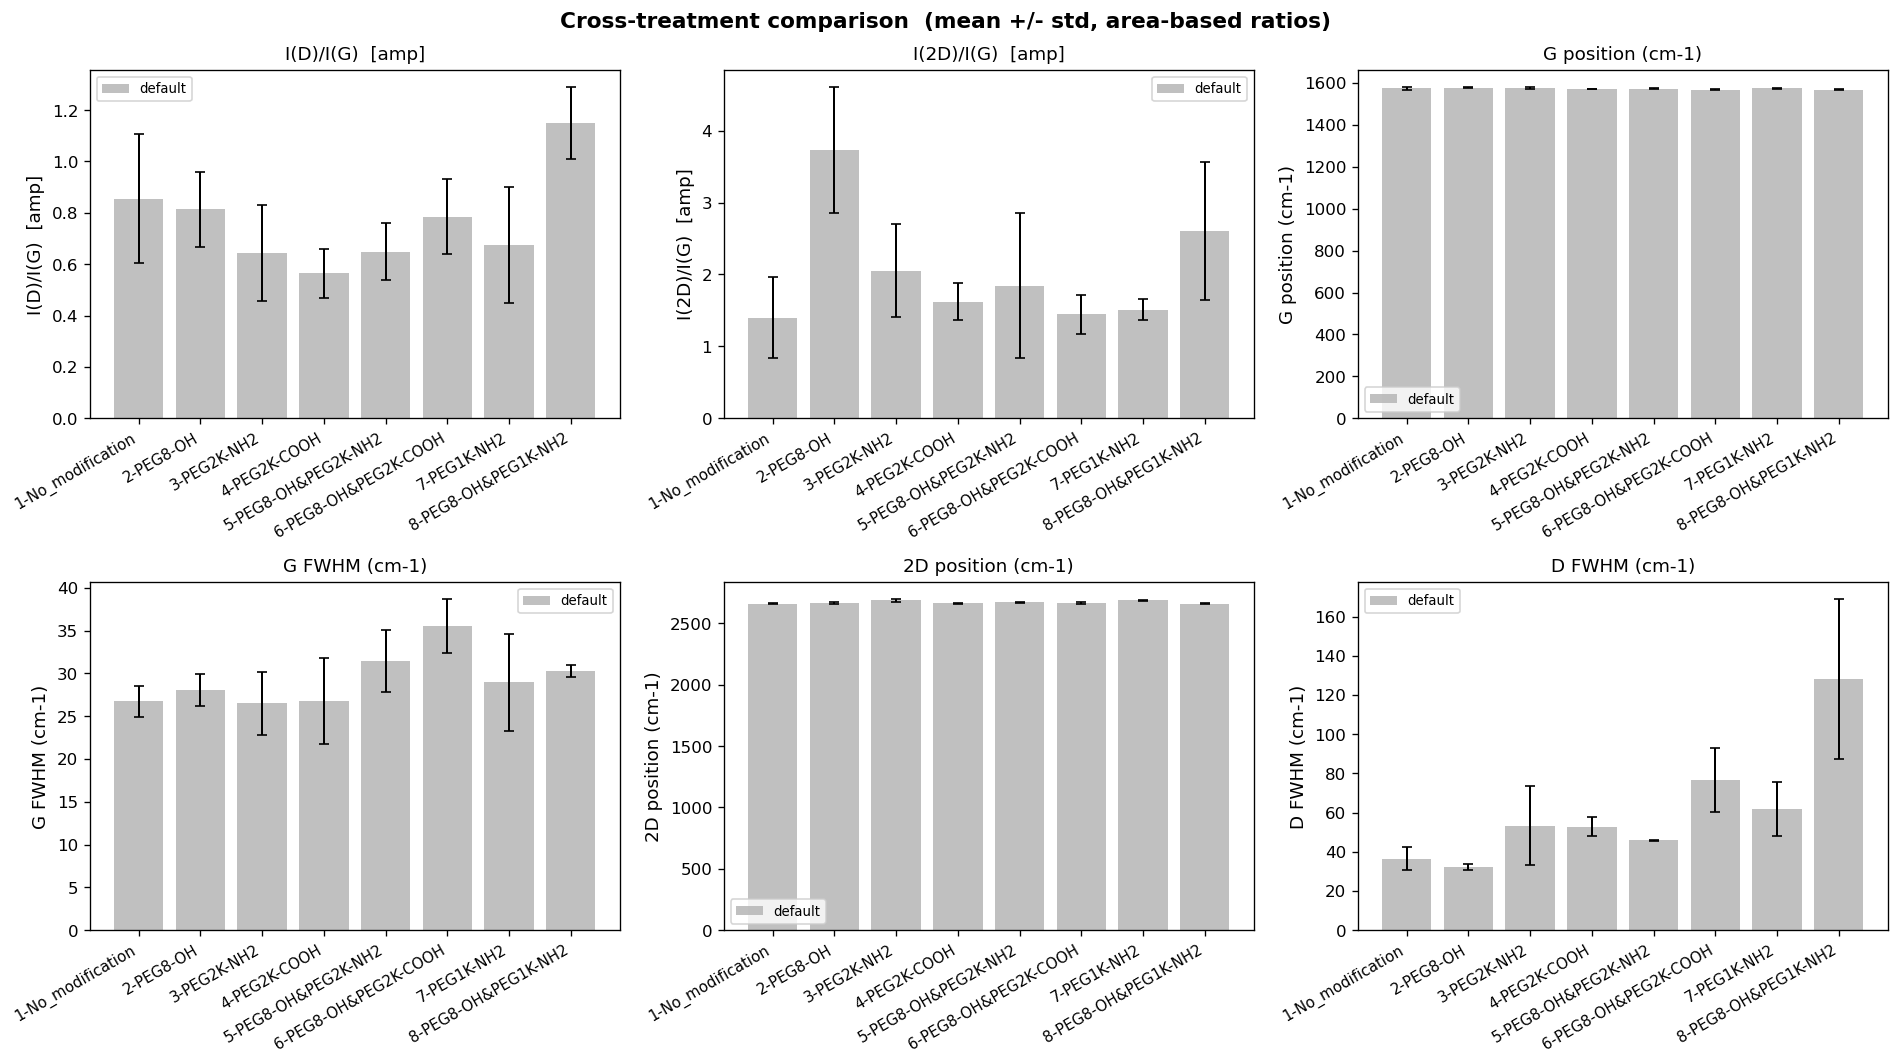

Saved to: /Users/leafylove/Desktop/Experiment/0_AffinityGrid/3-Graphene Characterization/1-Raman/GLM-copper/20260609/Analysis/output


,treatment,sample,file,D_pos,D_fwhm,D_amp,D_area,D_eta,D_rsq,G_pos,...,Dp_fwhm,Dp_area,TwoD_pos,TwoD_fwhm,TwoD_area,TwoD_rsq,DG_pos,DG_area,ID_IG,I2D_IG
0,default,1-No_modification,D_01.txt,1324.740,35.543,216.193,11957.566,0.971,0.971,1575.232,...,90.562,0.000,2654.342,40.466,22533.111,0.962,2920.000,3628.736,1.093,1.792
1,default,1-No_modification,D_02.txt,1328.986,31.541,153.954,7627.499,1.000,0.980,1579.263,...,26.694,0.000,2661.925,40.832,18550.774,0.974,2920.000,2958.642,0.879,1.652
2,default,1-No_modification,D_03.txt,1325.335,42.769,102.738,6902.016,1.000,0.944,1565.392,...,20.116,416.093,2658.876,42.398,8656.775,0.978,2920.024,2178.554,0.593,0.750
3,default,2-PEG8-OH,D_01.txt,1324.995,33.268,302.960,14926.539,0.823,0.988,1572.670,...,199.782,1871.794,2656.814,37.539,53485.132,0.971,2920.057,4437.921,0.934,2.797
4,default,2-PEG8-OH,D_02.txt,1333.517,30.404,1052.992,45172.975,0.684,0.991,1580.775,...,21.927,0.000,2670.588,36.392,417984.410,0.975,2923.218,26412.849,0.653,4.531
5,default,2-PEG8-OH,D_03.txt,1334.051,32.931,218.139,11283.979,1.000,0.981,1580.000,...,20.000,1200.913,2671.632,33.791,52529.280,0.975,2923.454,4465.637,0.856,3.883
6,default,3-PEG2K-NH2,D_01.txt,1343.665,40.685,62.809,4014.005,1.000,0.812,1575.380,...,199.973,1551.107,2690.125,33.603,5865.072,0.984,2920.000,1038.387,0.816,1.444
7,default,3-PEG2K-NH2,D_02.txt,1352.112,43.217,37.681,2557.948,1.000,0.841,1583.105,...,199.722,830.315,2704.077,30.092,8344.143,0.981,2961.819,2392.348,0.573,2.686
8,default,3-PEG2K-NH2,D_03.txt,1338.177,46.246,28.169,2046.294,1.000,0.959,1574.952,...,199.994,2217.315,2683.261,44.288,6418.936,0.975,2920.945,1125.588,0.776,2.543
9,default,3-PEG2K-NH2,D_04.txt,1329.529,83.363,59.056,6161.626,0.370,0.897,1571.462,...,199.998,3381.105,2667.610,41.640,14439.963,0.972,2920.000,1817.391,0.414,1.548


In [39]:
# ── Cross-treatment comparison + CSV export ───────────────────────────────────
master = pd.DataFrame(all_rows)
master.to_csv(OUTPUT_DIR / 'all_spectra_summary.csv', index=False, float_format='%.4f')

agg = (master
       .groupby(['treatment', 'sample'])[
           ['D_pos', 'D_fwhm', 'D_amp',
            'G_pos', 'G_fwhm', 'G_amp',
            'TwoD_pos', 'TwoD_fwhm', 'ID_IG', 'I2D_IG']]
       .agg(['mean', 'std'])
       .reset_index())
agg.columns = ['_'.join(c).strip('_') for c in agg.columns]
agg.to_csv(OUTPUT_DIR / 'sample_mean_std.csv', index=False, float_format='%.4f')

metrics = [
    ('ID_IG_mean',    'ID_IG_std',    'I(D)/I(G)  [amp]'),
    ('I2D_IG_mean',   'I2D_IG_std',   'I(2D)/I(G)  [amp]'),
    ('G_pos_mean',    'G_pos_std',    'G position (cm-1)'),
    ('G_fwhm_mean',   'G_fwhm_std',   'G FWHM (cm-1)'),
    ('TwoD_pos_mean', 'TwoD_pos_std', '2D position (cm-1)'),
    ('D_fwhm_mean',   'D_fwhm_std',   'D FWHM (cm-1)'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Cross-treatment comparison  (mean +/- std, area-based ratios)',
             fontsize=13, fontweight='bold')

for ax, (mc, sc, ylabel) in zip(axes.flatten(), metrics):
    for i, treatment in enumerate(t_list):
        sub = agg[agg['treatment'] == treatment]
        if sub.empty or mc not in agg.columns:
            continue
        x      = np.arange(len(sub))
        means  = sub[mc].values.astype(float)
        stds   = sub[sc].values.astype(float) if sc in agg.columns else np.zeros_like(means)
        offset = (i - len(t_list)/2 + 0.5) * 0.8 / max(len(t_list), 1)
        ax.bar(x + offset, means, width=0.8/max(len(t_list), 1),
               color=t_color[treatment], alpha=0.85, label=treatment)
        ax.errorbar(x + offset, means, yerr=np.nan_to_num(stds),
                    fmt='none', color='k', capsize=3, lw=1.2)
        if i == 0:
            ax.set_xticks(x)
            ax.set_xticklabels(sub['sample'].values,
                               rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'cross_treatment_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print('Saved to:', OUTPUT_DIR)
display(master.round(3))